# Mineração de Dados: Sistema de Recomendação de Músicas - Spotify

**Disciplina:** Tópicos Avançados em Computação IV  
**Projeto:** Mineração de Dados em Ciência de Dados  

**Participantes:**  
- Adriano André da Silva
- Gustavo Henrique de Brum
- Guilherme Júnior Machado
- João Pedro Oliveira Barbosa
- Jorge Miguel Eberhard da Conceição

---

Este notebook dá continuidade ao trabalho de pré-processamento realizado anteriormente sobre o **Spotify Tracks Dataset**. Nesta etapa, aplicamos duas técnicas de **mineração de dados não supervisionada** para construir um **sistema de recomendação de músicas** baseado em conteúdo (content-based). 

Técnicas escolhidas: KMeans Clustering e Similaridade de Cosseno

### Referências

- Aggarwal, C. C. (2016). *Recommender Systems*. Springer.
- Arthur, D., & Vassilvitskii, S. (2007). *k-means++: The Advantages of Careful Seeding*. SODA.
- Ricci, F., Rokach, L., & Shapira, B. (2015). *Recommender Systems Handbook*. Springer.
- Schedl, M., Zamani, H., Chen, C. W., et al. (2018). *Current Challenges and Visions in Music Recommender Systems Research*. IJMIR, 7(2).

---
## 0 - Imports e Configurações

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")

# Configurações visuais
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10
plt.rcParams["figure.figsize"] = (12, 6)

# Travar a semente para reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

---
## 1 - Carregamento e Exploração dos Dados

Utilizamos o dataset já pré-processado (`spotify_clean.csv`) gerado na etapa anterior. O normalizado anterior havia usado MinMaxScaler, o que não é o ideal para as técnicas aplicadas. Dessa forma, implementaremos StandardScaler aqui. 
Selecionamos as features de áudio que descrevem características sonoras objetivas de cada faixa. Excluímos metadados (artista, álbum, nome) e a coluna 'popularity' para que a recomendação seja puramente baseada no som.

In [25]:
# ============================================================
# 1.1 LEITURA DO DATASET
# ============================================================
print("=" * 72)
print("1.1 CARREGAMENTO E EXPLORAÇÃO INICIAL DO DATASET")
print("=" * 72)

df = pd.read_csv("spotify_clean.csv")

print(f"Shape do dataset: {df.shape[0]:,} registros × {df.shape[1]} atributos")
print(f'Gêneros únicos: {df["track_genre"].nunique()}')
print(f'Artistas únicos: {df["artists"].nunique()}')
print(f"\nPrimeiras linhas:")
df.head()

1.1 CARREGAMENTO E EXPLORAÇÃO INICIAL DO DATASET
Shape do dataset: 75,689 registros × 20 atributos
Gêneros únicos: 113
Artistas únicos: 29546

Primeiras linhas:


,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
0,Gen Hoshino,Comedy,Comedy,73.0,230666,False,0.676,0.4610,1,-6.7460,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,3.844433
1,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55.0,149610,False,0.420,0.1660,1,-17.2350,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,2.493500
2,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57.0,210826,False,0.438,0.3590,0,-9.7340,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,3.513767
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71.0,201933,False,0.266,0.0596,0,-18.1095,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,3.365550
4,Chord Overstreet,Hold On,Hold On,82.0,198853,False,0.618,0.4430,2,-9.6810,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,3.314217


In [26]:
# ============================================================
# 1.2 Features de áudio para modelagem
# ============================================================
print("=" * 72)
print("1.2 FEATURES DE ÁUDIO PARA MODELAGEM")
print("=" * 72)

# ------------------------------------------------------------
# Selecionar apenas as features de áudio relevantes para a modelagem
# ------------------------------------------------------------
AUDIO_FEATURES = [
    "danceability",  # Quão adequada é para dançar (0-1)
    "energy",  # Intensidade e atividade perceptual (0-1)
    "loudness",  # Volume geral em dB (-60 a 0)
    "speechiness",  # Presença de palavras faladas (0-1)
    "acousticness",  # Confiança de ser acústica (0-1)
    "instrumentalness",  # Predição de ausência de vocais (0-1)
    "liveness",  # Probabilidade de ser ao vivo (0-1)
    "valence",  # Positividade musical (0-1)
    "tempo",  # BPM estimado
    "duration_min",  # Duração em minutos
]

print(f"[1] Features selecionadas ({len(AUDIO_FEATURES)}):")
for i, f in enumerate(AUDIO_FEATURES, 1):
    print(f"  {i:2d}. {f}")

print(f"\n[2] Estatísticas descritivas das features de áudio:")
df[AUDIO_FEATURES].describe().round(3)

1.2 FEATURES DE ÁUDIO PARA MODELAGEM
[1] Features selecionadas (10):
   1. danceability
   2. energy
   3. loudness
   4. speechiness
   5. acousticness
   6. instrumentalness
   7. liveness
   8. valence
   9. tempo
  10. duration_min

[2] Estatísticas descritivas das features de áudio:


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min
count,75689.000,75689.000,75689.000,75689.000,75689.000,75689.000,75689.000,75689.000,75689.000,75689.000
mean,0.562,0.641,-8.173,0.069,0.323,0.092,0.204,0.466,122.647,3.766
std,0.175,0.255,4.137,0.045,0.335,0.152,0.151,0.262,29.621,1.307
min,0.091,0.000,-18.110,0.022,0.000,0.000,0.009,0.000,38.535,0.551
25%,0.451,0.465,-10.326,0.036,0.015,0.000,0.099,0.246,99.955,2.901
50%,0.575,0.681,-7.236,0.049,0.185,0.000,0.133,0.451,122.546,3.598
75%,0.691,0.859,-5.137,0.088,0.615,0.147,0.285,0.677,140.902,4.468
max,0.985,1.000,-0.001,0.165,0.996,0.367,0.564,0.995,202.322,6.818


1.3 DISTRIBUIÇÃO DAS FEATURES DE ÁUDIO


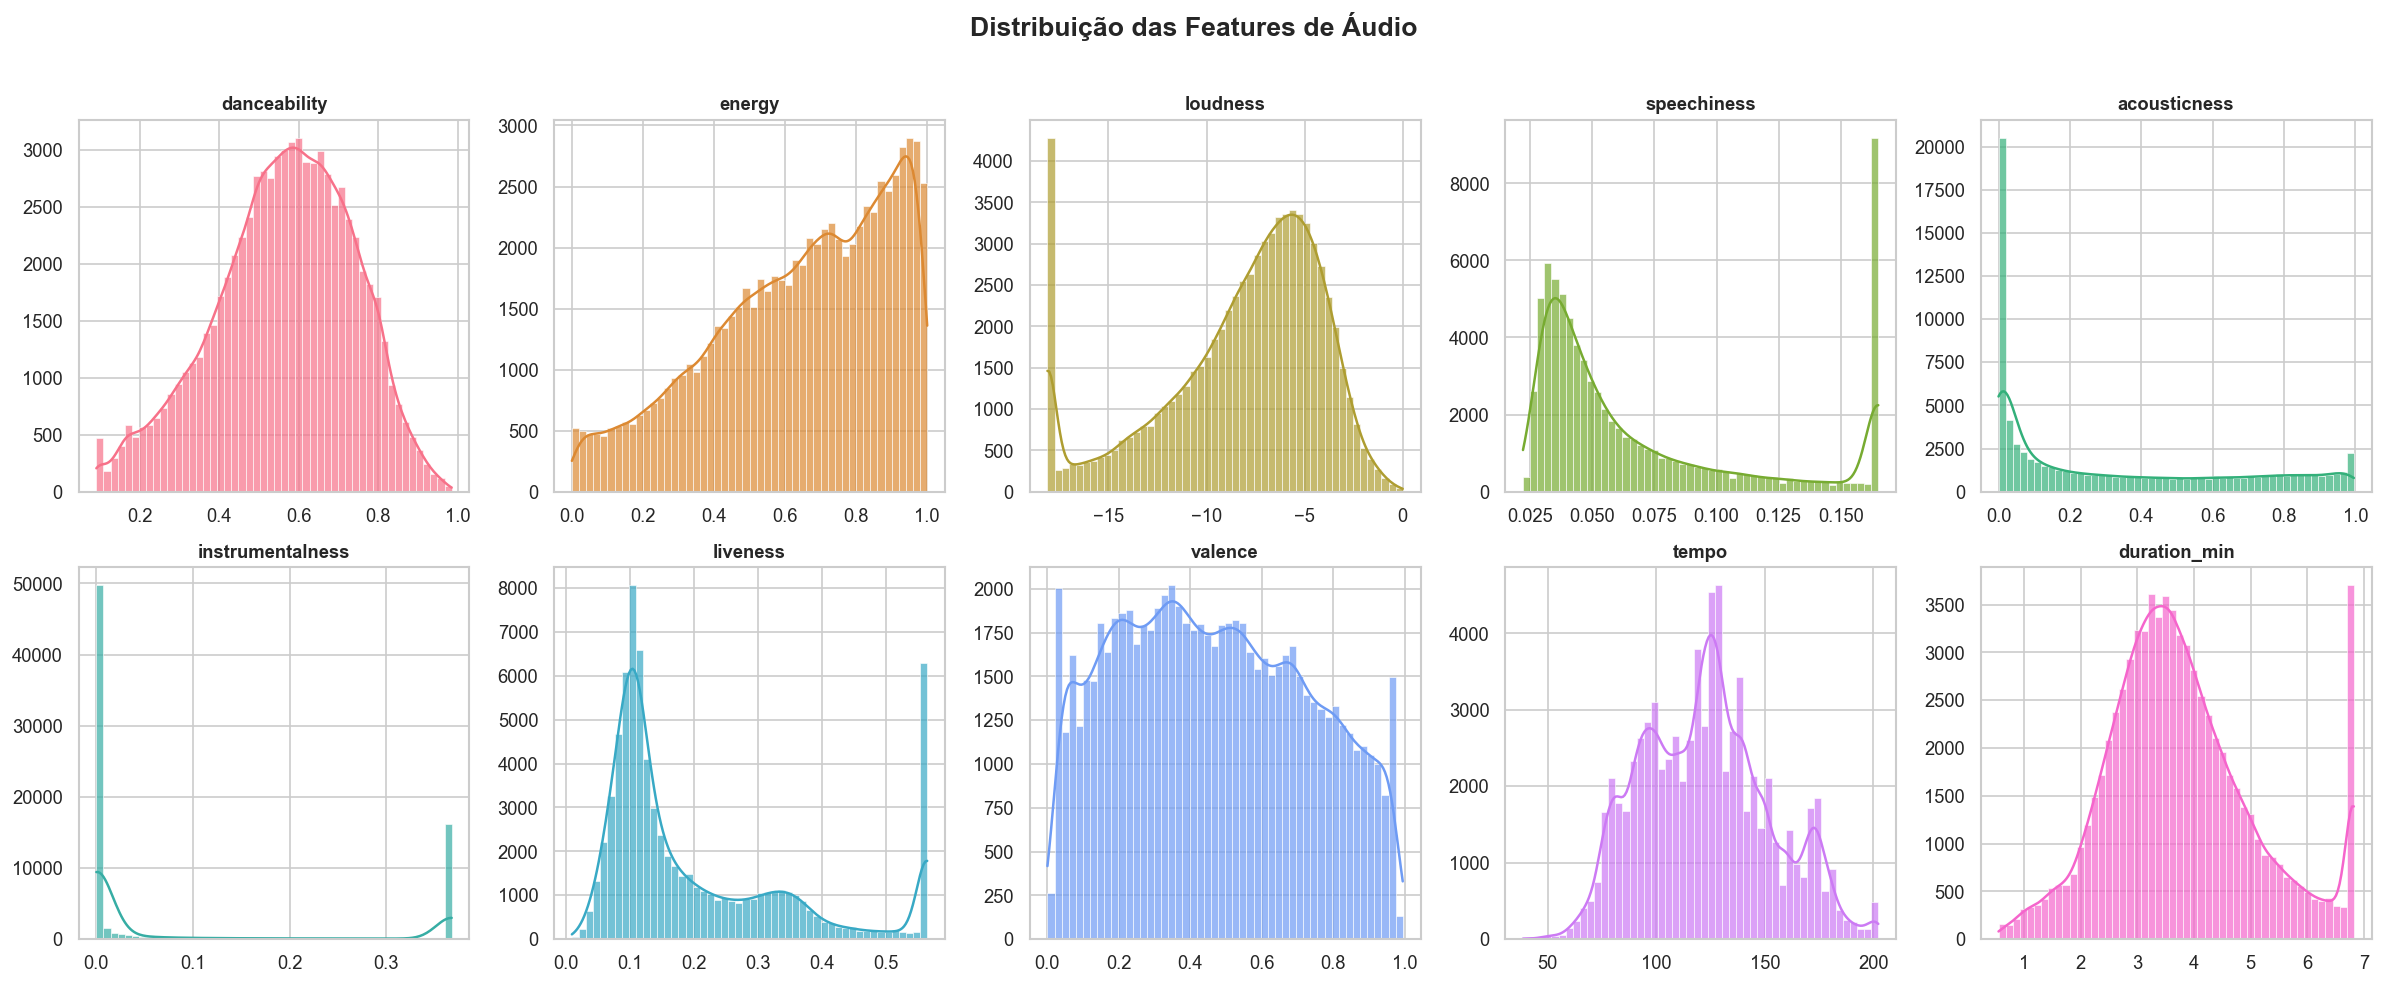

Gráfico salvo em resultados/11_distribuicao_features.png


In [27]:
# ============================================================
# 1.3 Distribuição das features de áudio
# ============================================================
print("=" * 72)
print("1.3 DISTRIBUIÇÃO DAS FEATURES DE ÁUDIO")
print("=" * 72)

# ------------------------------------------------------------
# Visualizar a distribuição de cada feature de áudio usando histogramas
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle(
    "Distribuição das Features de Áudio", fontsize=16, fontweight="bold", y=1.02
)

colors = sns.color_palette("husl", len(AUDIO_FEATURES))

for idx, (feature, ax) in enumerate(zip(AUDIO_FEATURES, axes.flatten())):
    sns.histplot(df[feature], ax=ax, color=colors[idx], kde=True, bins=50, alpha=0.7)
    ax.set_title(feature, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.savefig("resultados/11_distribuicao_features.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico salvo em resultados/11_distribuicao_features.png")

1.4 MATRIZ DE CORRELAÇÃO ENTRE FEATURES


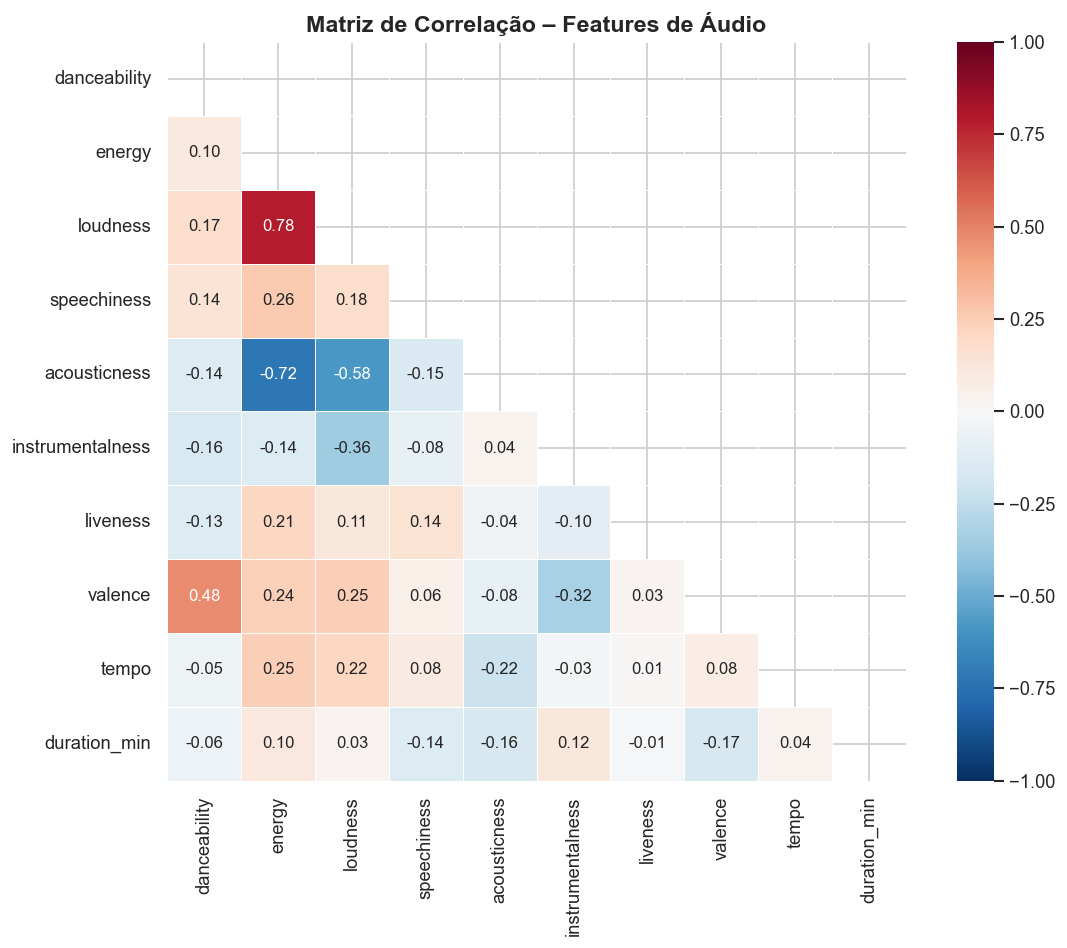

Gráfico salvo em resultados/12_correlacao_features.png

[1] Correlações mais fortes (|r| > 0.3):
  • danceability ↔ valence: 0.475
  • energy ↔ loudness: 0.782
  • energy ↔ acousticness: -0.724
  • loudness ↔ acousticness: -0.584
  • loudness ↔ instrumentalness: -0.358
  • instrumentalness ↔ valence: -0.321


In [48]:
# ============================================================
# 1.4 Matriz de correlação entre features
# ============================================================
print("=" * 72)
print("1.4 MATRIZ DE CORRELAÇÃO ENTRE FEATURES")
print("=" * 72)

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df[AUDIO_FEATURES].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Matriz de Correlação – Features de Áudio", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("resultados/12_correlacao_features.png", dpi=150, bbox_inches="tight")
plt.show()

print("Gráfico salvo em resultados/12_correlacao_features.png")

# Destacar correlações fortes
print("\n[1] Correlações mais fortes (|r| > 0.3):")
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.3:
            print(f"  • {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: {val:.3f}")

---
## 2 - Preparação dos Dados para Modelagem

Antes de aplicar as técnicas de mineração, é necessário **padronizar** as features, pois elas possuem escalas diferentes. O `StandardScaler` transforma cada feature para média 0 e desvio padrão 1, conforme recomendado por Jain (2010) para algoritmos baseados em distância.

Posteriormente, a Análise de Componentes Principais (PCA) é usada para: 
(1) visualização 2D dos clusters, e
(2) remover ruído e correlações entre features. 

Segundo Jolliffe (2002), reter componentes que expliquem pelo menos 80% da variância é uma boa prática.

In [29]:
# ============================================================
# 2.1 Padronização (StandardScaler)
# ============================================================
print("=" * 72)
print("2.1 PADRONIZAÇÃO (STANDARDSCALER)")
print("=" * 72)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[AUDIO_FEATURES])

# Converter para DataFrame para facilitar manipulação
df_scaled = pd.DataFrame(X_scaled, columns=AUDIO_FEATURES, index=df.index)

print("[1] Padronização aplicada com StandardScaler")
print(f"\n[2] Shape dos dados padronizados: {X_scaled.shape}")
print(f"\n[3] Verificação (média ≈ 0, std ≈ 1):")
print(df_scaled.describe().loc[["mean", "std"]].round(4))

2.1 PADRONIZAÇÃO (STANDARDSCALER)
[1] Padronização aplicada com StandardScaler

[2] Shape dos dados padronizados: (75689, 10)

[3] Verificação (média ≈ 0, std ≈ 1):
      danceability  energy  loudness  speechiness  acousticness  \
mean           0.0     0.0       0.0         -0.0           0.0   
std            1.0     1.0       1.0          1.0           1.0   

      instrumentalness  liveness  valence  tempo  duration_min  
mean               0.0       0.0     -0.0    0.0          -0.0  
std                1.0       1.0      1.0    1.0           1.0  


2.2 REDUÇÃO DE DIMENSIONALIDADE COM PCA


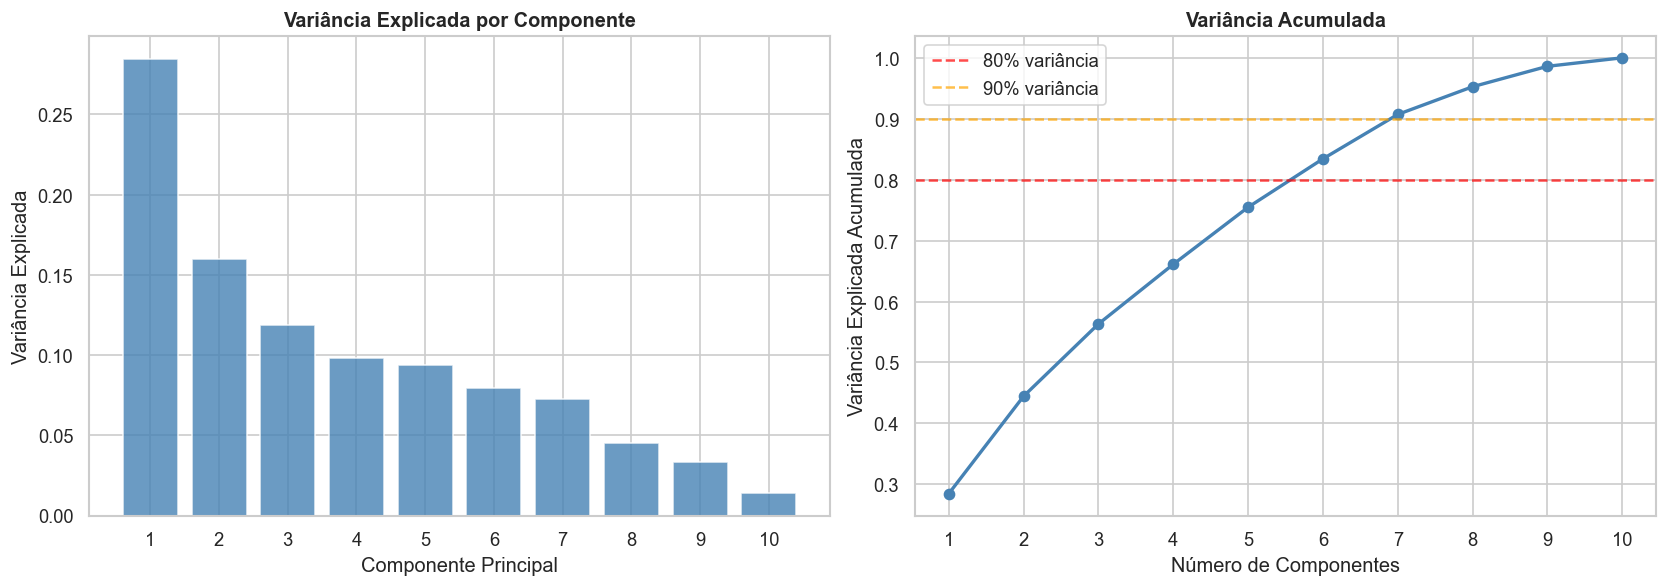


[1] Componentes mínimos por limiar de variância:
    80% da informação → 6 de 10 dimensões são suficientes
    90% da informação → 7 de 10 dimensões são suficientes
    Escolhemos 6 componentes: eliminamos 4 dimensão(ões) com baixa contribuição informacional

[2] PCA aplicado: 10 features originais → 6 componentes principais
    Cada música era descrita por 10 valores e agora 6 componentes representam o mesmo perfil sonoro

[3] Variância retida: 83.42%
    83.42% da informação original foi preservada, perdemos apenas 16.58% ao comprimir as dimensões


In [30]:
# ============================================================
# 2.2 Redução de Dimensionalidade com PCA
# ============================================================
print("=" * 72)
print("2.2 REDUÇÃO DE DIMENSIONALIDADE COM PCA")
print("=" * 72)

# Treina o PCA com todas as features para ver quanto cada componente explica
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

# Dois gráficos lado a lado: variância por componente e variância acumulada
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Barras: quanto cada componente contribui individualmente para a variância total
ax1.bar(
    range(1, len(AUDIO_FEATURES) + 1),
    pca_full.explained_variance_ratio_,
    color="steelblue",
    alpha=0.8,
)
ax1.set_xlabel("Componente Principal")
ax1.set_ylabel("Variância Explicada")
ax1.set_title("Variância Explicada por Componente", fontweight="bold")
ax1.set_xticks(range(1, len(AUDIO_FEATURES) + 1))

# Linha acumulada: mostra quantos componentes são necessários para atingir 80% ou 90%
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
ax2.plot(
    range(1, len(AUDIO_FEATURES) + 1), cumvar, "o-", color="steelblue", linewidth=2
)
ax2.axhline(y=0.80, color="red", linestyle="--", alpha=0.7, label="80% variância")
ax2.axhline(y=0.90, color="orange", linestyle="--", alpha=0.7, label="90% variância")
ax2.set_xlabel("Número de Componentes")
ax2.set_ylabel("Variância Explicada Acumulada")
ax2.set_title("Variância Acumulada", fontweight="bold")
ax2.set_xticks(range(1, len(AUDIO_FEATURES) + 1))
ax2.legend()

plt.tight_layout()
plt.savefig("resultados/13_pca_variancia.png", dpi=150, bbox_inches="tight")
plt.show()

# Encontra o menor número de componentes que atinge 80% e 90% de variância
n_components_80 = np.argmax(cumvar >= 0.80) + 1
n_components_90 = np.argmax(cumvar >= 0.90) + 1

print(f"\n[1] Componentes mínimos por limiar de variância:")
print(
    f"    80% da informação → {n_components_80} de {len(AUDIO_FEATURES)} dimensões são suficientes"
)
print(
    f"    90% da informação → {n_components_90} de {len(AUDIO_FEATURES)} dimensões são suficientes"
)
print(
    f"    Escolhemos {n_components_80} componentes: eliminamos {len(AUDIO_FEATURES) - n_components_80} dimensão(ões) com baixa contribuição informacional"
)

# Aplica o PCA final reduzindo as features ao número mínimo de componentes necessários
N_COMPONENTS = n_components_80
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(
    f"\n[2] PCA aplicado: {X_scaled.shape[1]} features originais → {N_COMPONENTS} componentes principais"
)
print(
    f"    Cada música era descrita por {X_scaled.shape[1]} valores e agora {N_COMPONENTS} componentes representam o mesmo perfil sonoro"
)

print(f"\n[3] Variância retida: {pca.explained_variance_ratio_.sum():.2%}")
print(
    f"    {pca.explained_variance_ratio_.sum():.2%} da informação original foi preservada, perdemos apenas {1 - pca.explained_variance_ratio_.sum():.2%} ao comprimir as dimensões"
)

---
## 3 - Técnica 1: KMeans Clustering

O **KMeans** é um algoritmo de particionamento que divide os dados em $k$ clusters, minimizando a soma das distâncias ao quadrado entre cada ponto e o centróide do seu cluster (inércia). Segundo Arthur & Vassilvitskii (2007), a inicialização **k-means++** melhora significativamente a convergência.

Dessa forma, nosso objetivo será identificar **perfis sonoros** naturais no catálogo do Spotify, agrupando músicas com características acústicas semelhantes.

### Parâmetros

| Parâmetro | Valor | Justificativa |
|-----------|-------|---------------|
| `n_clusters` | Determinado por Elbow + Silhouette | Escolha orientada por dados |
| `init` | `k-means++` | Inicialização inteligente (Arthur & Vassilvitskii, 2007) |
| `n_init` | 10 | Múltiplas inicializações para robustez |
| `max_iter` | 300 | Convergência garantida |
| `random_state` | 42 | Reprodutibilidade |

3.1 DETERMINAÇÃO DO NÚMERO ÓTIMO DE CLUSTERS - ELBOW + SILHOUETTE SCORE
Testando valores de k de 2 a 10...
  k= 2 | Inércia:      483,391 | Silhouette: 0.2481
  k= 3 | Inércia:      419,580 | Silhouette: 0.1772
  k= 4 | Inércia:      378,975 | Silhouette: 0.1772
  k= 5 | Inércia:      348,247 | Silhouette: 0.1692
  k= 6 | Inércia:      319,696 | Silhouette: 0.1736
  k= 7 | Inércia:      296,963 | Silhouette: 0.1779
  k= 8 | Inércia:      281,723 | Silhouette: 0.1658
  k= 9 | Inércia:      268,390 | Silhouette: 0.1654
  k=10 | Inércia:      259,015 | Silhouette: 0.1664


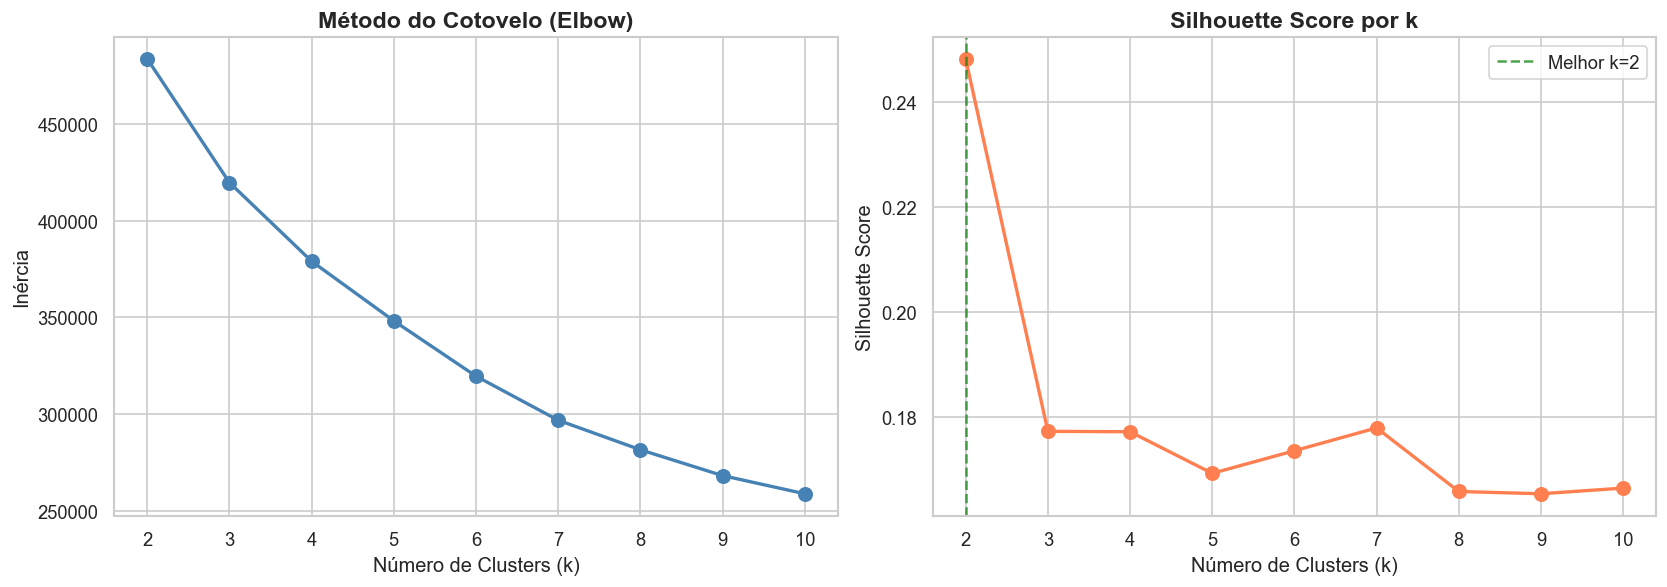


[1] Melhor k pelo Silhouette Score: 2 (score = 0.2481)
    Esse k indica a melhor separação estatística entre os clusters


In [ ]:
# ============================================================
# 3.1 Determinação do número ótimo de clusters
# ============================================================
print("=" * 72)
print("3.1 DETERMINAÇÃO DO NÚMERO ÓTIMO DE CLUSTERS - ELBOW + SILHOUETTE SCORE")
print("=" * 72)

K_RANGE = range(2, 11)
inertias = []
silhouette_scores = []

print("Testando valores de k de 2 a 10...")
for k in K_RANGE:
    kmeans_temp = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=RANDOM_STATE,
    )
    labels_temp = kmeans_temp.fit_predict(X_pca)
    inertias.append(kmeans_temp.inertia_)
    sil_score = silhouette_score(
        X_pca, labels_temp, sample_size=10000, random_state=RANDOM_STATE
    )
    silhouette_scores.append(sil_score)
    print(
        f"  k={k:2d} | Inércia: {kmeans_temp.inertia_:>12,.0f} | Silhouette: {sil_score:.4f}"
    )

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_RANGE, inertias, "o-", color="steelblue", linewidth=2, markersize=8)
ax1.set_xlabel("Número de Clusters (k)", fontsize=12)
ax1.set_ylabel("Inércia", fontsize=12)
ax1.set_title("Método do Cotovelo (Elbow)", fontsize=14, fontweight="bold")
ax1.set_xticks(list(K_RANGE))

best_k = list(K_RANGE)[np.argmax(silhouette_scores)]
ax2.plot(K_RANGE, silhouette_scores, "o-", color="coral", linewidth=2, markersize=8)
ax2.axvline(
    x=best_k, color="green", linestyle="--", alpha=0.7, label=f"Melhor k={best_k}"
)
ax2.set_xlabel("Número de Clusters (k)", fontsize=12)
ax2.set_ylabel("Silhouette Score", fontsize=12)
ax2.set_title("Silhouette Score por k", fontsize=14, fontweight="bold")
ax2.set_xticks(list(K_RANGE))
ax2.legend(fontsize=11)

plt.tight_layout()
plt.savefig("resultados/14_elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

print(
    f"\n[1] Melhor k pelo Silhouette Score: {best_k} (score = {max(silhouette_scores):.4f})"
)
print(f"    Esse k indica a melhor separação estatística entre os clusters")

In [ ]:
# ============================================================
# 3.2 Treinamento do KMeans com k ótimo
# ============================================================
print("=" * 72)
print("3.2 TREINAMENTO DO KMEANS COM K ÓTIMO")
print("=" * 72)

# k=5 via Elbow Method — compromisso entre granularidade e coesão (Kodinariya & Makwana, 2013)
OPTIMAL_K = 5

print(f"[1] k escolhido: {OPTIMAL_K}")
print(
    f"    Silhouette sugere k={best_k}, mas k=2 gera apenas 2 grupos, insuficiente para a diversidade sonora"
)
print(f"    Utilizamos k={OPTIMAL_K} baseado no Elbow Method + análise de domínio")

print(f"\n[2] Treinando KMeans com k = {OPTIMAL_K}...")

kmeans = KMeans(
    n_clusters=OPTIMAL_K,
    init="k-means++",
    n_init=10,
    max_iter=300,
    random_state=RANDOM_STATE,
)

df["cluster"] = kmeans.fit_predict(X_pca)

print(f"\n[3] Clustering concluído!")

print(f"\n[4] Distribuição dos clusters:")
cluster_counts = df["cluster"].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    pct = count / len(df) * 100
    print(f"    Cluster {cluster_id}: {count:>6,} músicas ({pct:.1f}%)")

final_sil = silhouette_score(
    X_pca, df["cluster"], sample_size=10000, random_state=RANDOM_STATE
)
print(f"\n[5] Silhouette Score final (k={OPTIMAL_K}): {final_sil:.4f}")
print(
    f"    Score entre 0 e 1 — quanto mais próximo de 1, melhor a separação dos clusters"
)

3.2 TREINAMENTO DO KMEANS COM K ÓTIMO
[1] k escolhido: 5
    Silhouette sugere k=2, mas k=2 é muito grosseiro para capturar a diversidade sonora
    Utilizamos k=5 baseado no Elbow Method + análise de domínio

[2] Treinando KMeans com k = 5...

[3] Clustering concluído!

[4] Distribuição dos clusters:
  Cluster 0: 23,393 músicas (30.9%)
  Cluster 1:  7,320 músicas (9.7%)
  Cluster 2: 14,400 músicas (19.0%)
  Cluster 3: 16,303 músicas (21.5%)
  Cluster 4: 14,273 músicas (18.9%)

[5] Silhouette Score final (k=5): 0.1692
    Score entre 0 e 1 — quanto mais próximo de 1, melhor a separação dos clusters


3.3 VISUALIZAÇÃO DOS CLUSTERS COM PCA 2D


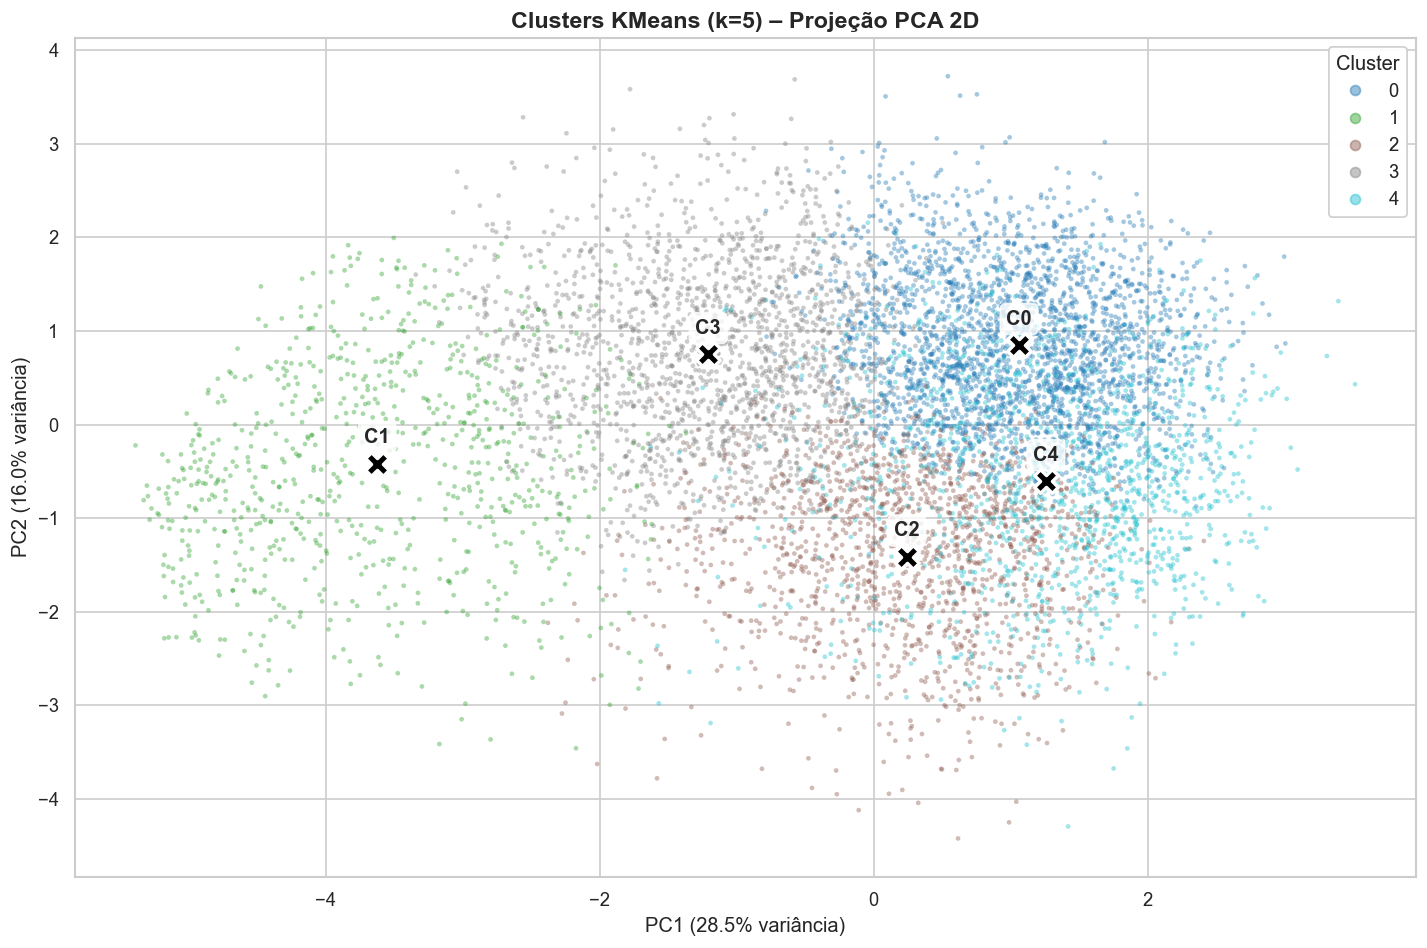


[1] Variância explicada pela projeção 2D: 44.45%
    As 6 dimensões do PCA foram reduzidas a 2 apenas para visualização no plano cartesiano


In [ ]:
# ============================================================
# 3.3 Visualização dos clusters com PCA 2D
# ============================================================
print("=" * 72)
print("3.3 VISUALIZAÇÃO DOS CLUSTERS COM PCA 2D")
print("=" * 72)

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_2d.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(12, 8))

# Amostra de 8.000 pontos para performance
sample_idx = np.random.choice(len(df), size=min(8000, len(df)), replace=False)

scatter = ax.scatter(
    X_2d[sample_idx, 0],
    X_2d[sample_idx, 1],
    c=df["cluster"].values[sample_idx],
    cmap="tab10",
    alpha=0.4,
    s=8,
    edgecolors="none",
)

centroids_2d = pca_2d.transform(
    scaler.inverse_transform(pca.inverse_transform(kmeans.cluster_centers_)).reshape(
        OPTIMAL_K, -1
    )
)

# Centróides posicionados pela média de cada cluster
for c in range(OPTIMAL_K):
    mask = df["cluster"].values == c
    cx, cy = X_2d[mask, 0].mean(), X_2d[mask, 1].mean()
    ax.scatter(
        cx, cy, c="black", marker="X", s=200, edgecolors="white", linewidth=2, zorder=5
    )
    ax.annotate(
        f"C{c}",
        (cx, cy),
        fontsize=12,
        fontweight="bold",
        ha="center",
        va="bottom",
        xytext=(0, 10),
        textcoords="offset points",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
    )

ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variância)", fontsize=12)
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variância)", fontsize=12)
ax.set_title(
    f"Clusters KMeans (k={OPTIMAL_K}) – Projeção PCA 2D", fontsize=14, fontweight="bold"
)

legend = ax.legend(*scatter.legend_elements(), title="Cluster", loc="upper right")
ax.add_artist(legend)

plt.tight_layout()
plt.savefig("resultados/15_clusters_pca2d.png", dpi=150, bbox_inches="tight")
plt.show()

print(
    f"\n[1] Variância explicada pela projeção 2D: {pca_2d.explained_variance_ratio_.sum():.2%}"
)
print(
    f"    As {N_COMPONENTS} dimensões do PCA foram reduzidas a 2 apenas para visualização no plano cartesiano"
)

3.4 PERFIL SONORO DOS CLUSTERS - HEATMAP


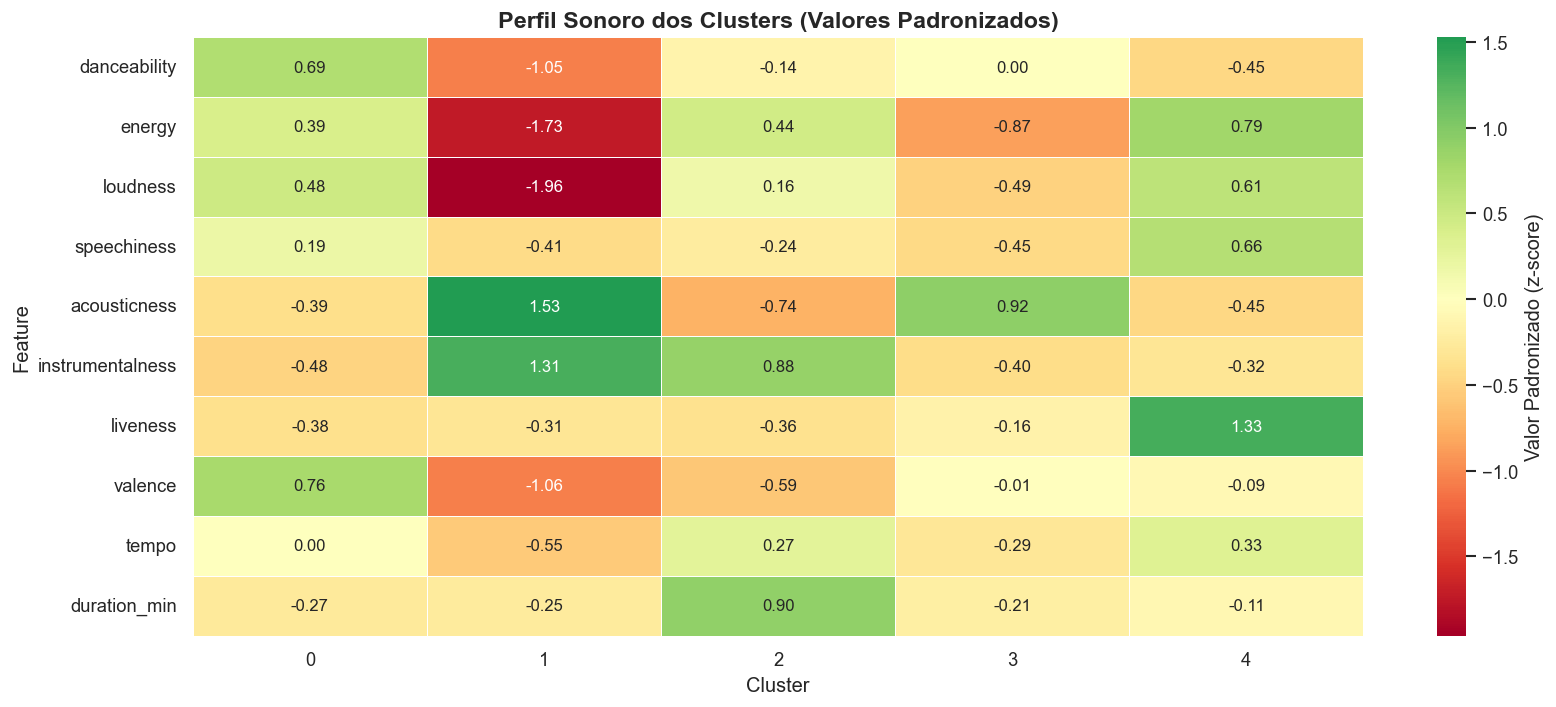

In [ ]:
# ============================================================
# 3.4 Perfil sonoro de cada cluster (Heatmap)
# ============================================================
print("=" * 72)
print("3.4 PERFIL SONORO DOS CLUSTERS - HEATMAP")
print("=" * 72)

df_scaled["cluster"] = df["cluster"].values
cluster_profiles = df_scaled.groupby("cluster")[AUDIO_FEATURES].mean()

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    cluster_profiles.T,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Valor Padronizado (z-score)"},
)
ax.set_title(
    "Perfil Sonoro dos Clusters (Valores Padronizados)", fontsize=14, fontweight="bold"
)
ax.set_xlabel("Cluster", fontsize=12)
ax.set_ylabel("Feature", fontsize=12)

plt.tight_layout()
plt.savefig("resultados/16_cluster_profiles_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

3.5 RADAR CHART - PERFIL SONORO POR CLUSTER


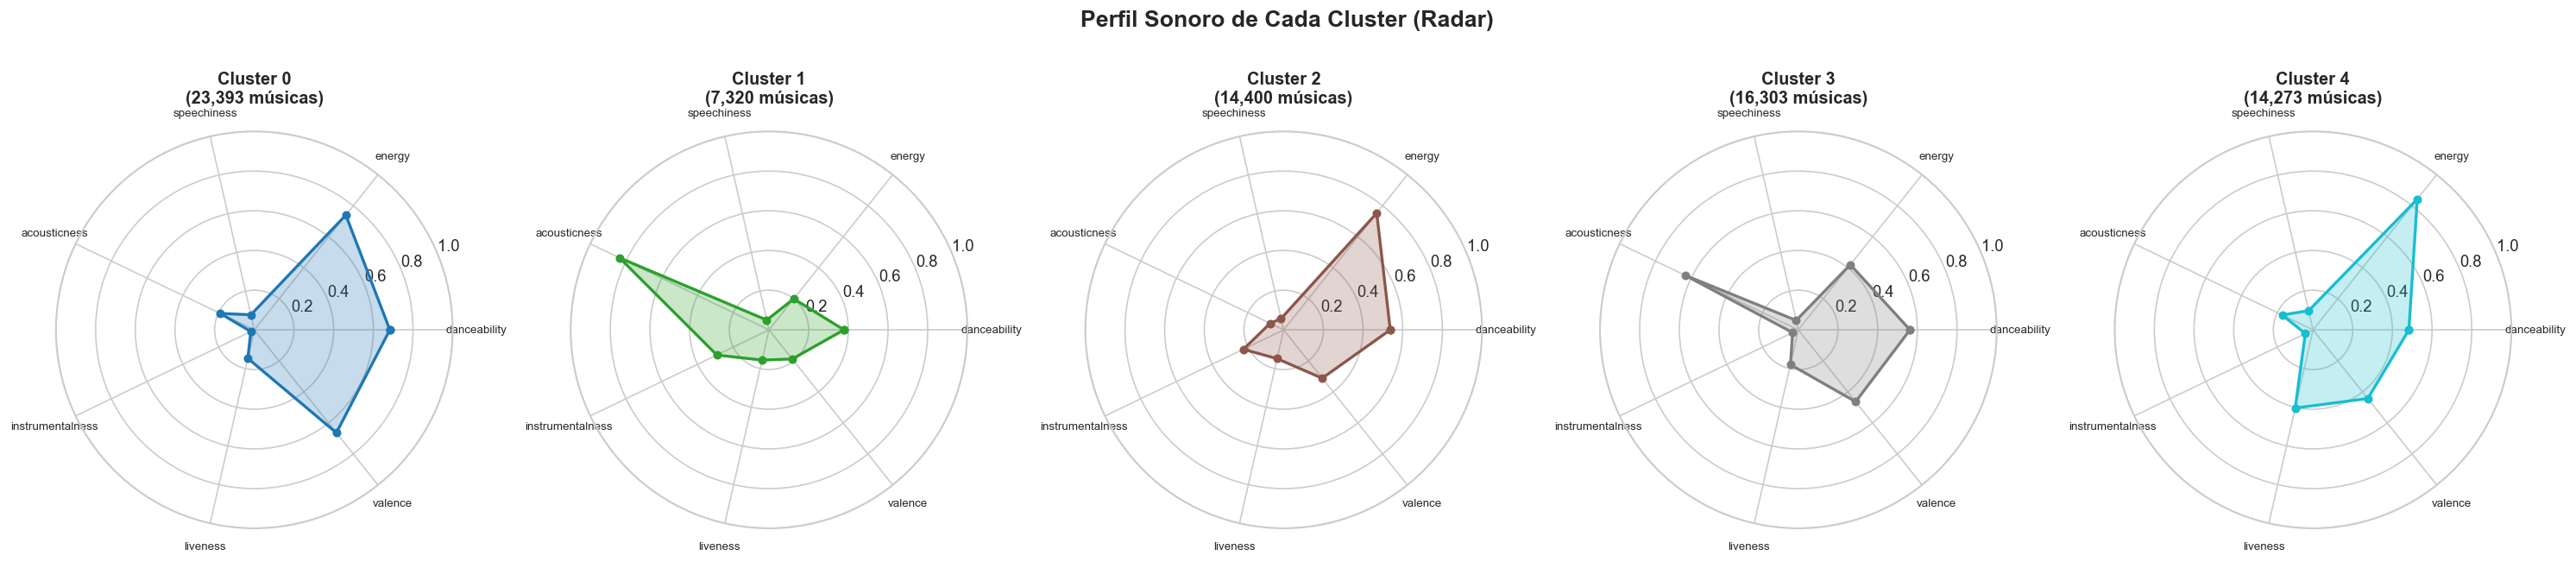

In [ ]:
# ============================================================
# 3.5 Radar Chart - Perfil de cada cluster
# ============================================================
print("=" * 72)
print("3.5 RADAR CHART - PERFIL SONORO POR CLUSTER")
print("=" * 72)

from sklearn.preprocessing import MinMaxScaler

radar_features = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
]

cluster_radar = df.groupby("cluster")[radar_features].mean()

num_vars = len(radar_features)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(
    1, OPTIMAL_K, figsize=(5 * OPTIMAL_K, 5), subplot_kw=dict(polar=True)
)
if OPTIMAL_K == 1:
    axes = [axes]

colors = plt.cm.tab10(np.linspace(0, 1, OPTIMAL_K))

for idx, (cluster_id, row) in enumerate(cluster_radar.iterrows()):
    ax = axes[idx]
    values = row.tolist()
    values += values[:1]

    ax.fill(angles, values, color=colors[idx], alpha=0.25)
    ax.plot(angles, values, "o-", color=colors[idx], linewidth=2, markersize=5)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_features, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_title(
        f"Cluster {cluster_id}\n({cluster_counts[cluster_id]:,} músicas)",
        fontsize=12,
        fontweight="bold",
        pad=20,
    )

fig.suptitle(
    "Perfil Sonoro de Cada Cluster (Radar)", fontsize=16, fontweight="bold", y=1.05
)
plt.tight_layout()
plt.savefig("resultados/17_cluster_radar.png", dpi=150, bbox_inches="tight")
plt.show()

3.6 GÊNEROS PREDOMINANTES POR CLUSTER
Top 5 gêneros por cluster:

  Cluster 0 (23,393 músicas):
    • kids: 721 (3.1%)
    • forro: 650 (2.8%)
    • dancehall: 634 (2.7%)
    • salsa: 583 (2.5%)
    • afrobeat: 528 (2.3%)

  Cluster 1 (7,320 músicas):
    • new-age: 779 (10.6%)
    • ambient: 662 (9.0%)
    • sleep: 569 (7.8%)
    • disney: 513 (7.0%)
    • opera: 433 (5.9%)

  Cluster 2 (14,400 músicas):
    • detroit-techno: 745 (5.2%)
    • minimal-techno: 722 (5.0%)
    • black-metal: 650 (4.5%)
    • chicago-house: 647 (4.5%)
    • drum-and-bass: 560 (3.9%)

  Cluster 3 (16,303 músicas):
    • tango: 740 (4.5%)
    • honky-tonk: 704 (4.3%)
    • cantopop: 687 (4.2%)
    • acoustic: 556 (3.4%)
    • bluegrass: 550 (3.4%)

  Cluster 4 (14,273 músicas):
    • comedy: 694 (4.9%)
    • grindcore: 669 (4.7%)
    • heavy-metal: 470 (3.3%)
    • pagode: 467 (3.3%)
    • hardstyle: 445 (3.1%)



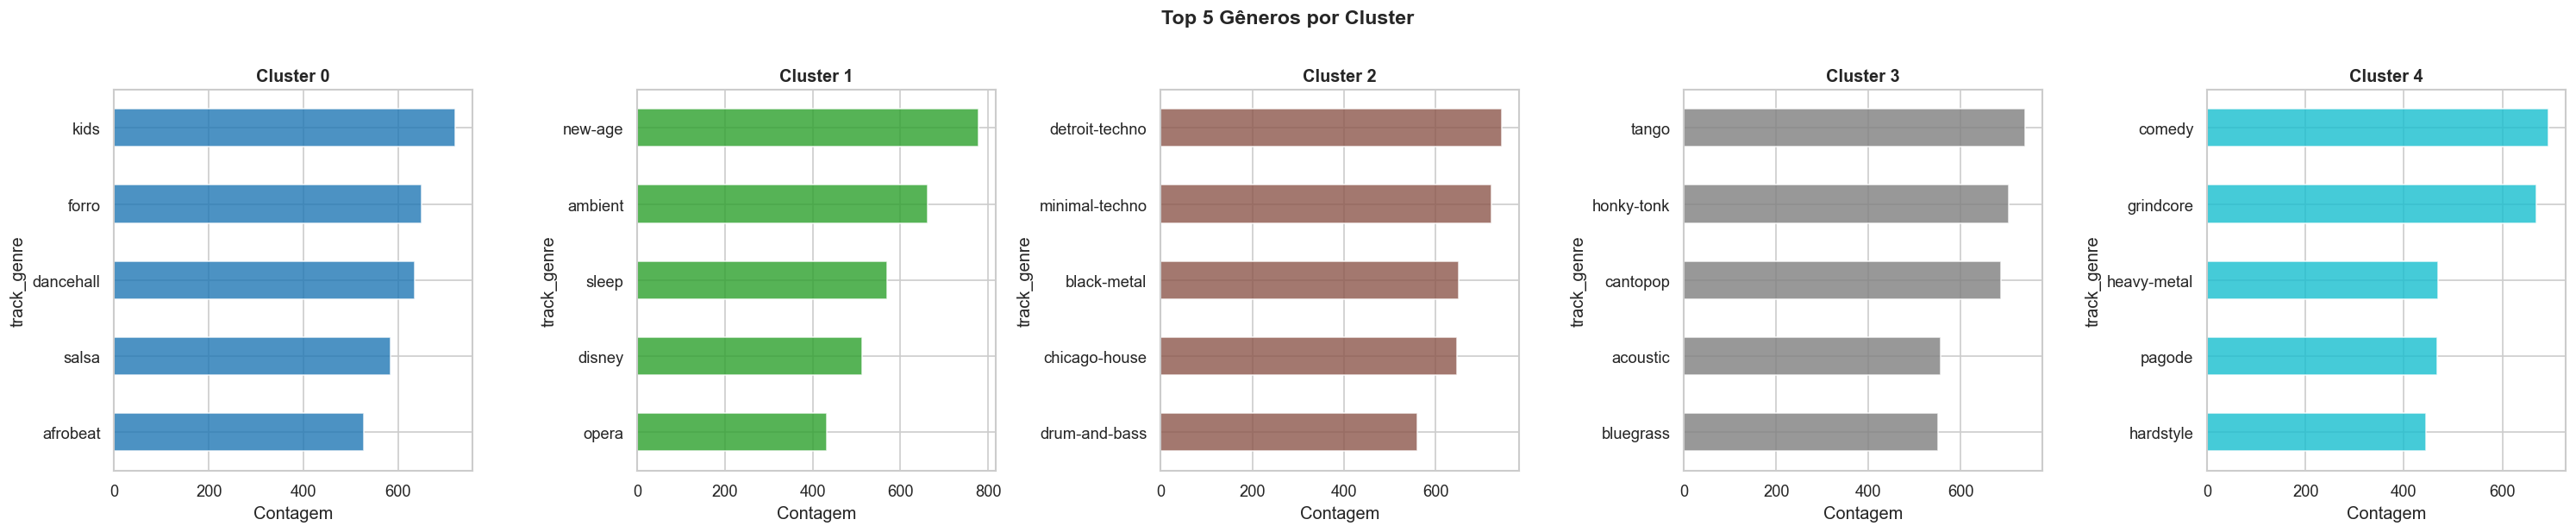

In [ ]:
# ============================================================
# 3.6 Gêneros predominantes por cluster
# ============================================================
print("=" * 72)
print("3.6 GÊNEROS PREDOMINANTES POR CLUSTER")
print("=" * 72)

print("Top 5 gêneros por cluster:\n")

fig, axes = plt.subplots(1, OPTIMAL_K, figsize=(5 * OPTIMAL_K, 5))
if OPTIMAL_K == 1:
    axes = [axes]

for cluster_id in range(OPTIMAL_K):
    cluster_data = df[df["cluster"] == cluster_id]
    top_genres = cluster_data["track_genre"].value_counts().head(5)

    print(f"  Cluster {cluster_id} ({len(cluster_data):,} músicas):")
    for genre, count in top_genres.items():
        pct = count / len(cluster_data) * 100
        print(f"    - {genre}: {count} ({pct:.1f}%)")
    print()

    ax = axes[cluster_id]
    top_genres.plot(kind="barh", ax=ax, color=colors[cluster_id], alpha=0.8)
    ax.set_title(f"Cluster {cluster_id}", fontweight="bold")
    ax.set_xlabel("Contagem")
    ax.invert_yaxis()

fig.suptitle("Top 5 Gêneros por Cluster", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("resultados/18_generos_por_cluster.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.7 Interpretação dos Clusters

Os clusters encontrados representam **perfis sonoros distintos** dentro do catálogo Spotify. A análise dos radar charts e dos gêneros predominantes permite atribuir significado semântico a cada agrupamento. Essa segmentação é valiosa porque demonstra que os atributos de áudio capturam diferenças perceptuais reais entre estilos musicais, corroborando os achados de McFee et al. (2012) sobre a eficácia de features de áudio na organização de catálogos musicais.

---
## 4 - Técnica 2: Similaridade de Cosseno (Content-Based Filtering)

A **Similaridade de Cosseno** mede o cosseno do ângulo entre dois vetores, variando de -1 (opostos) a 1 (idênticos). É a métrica mais utilizada em sistemas de recomendação baseados em conteúdo (Ricci et al., 2015) porque:

- É **invariante à magnitude** (foca na direção/proporção das features);
- É eficiente computacionalmente;
- Produz scores interpretáveis entre 0 e 1 (para vetores positivos).

$$\text{sim}(A, B) = \frac{A \cdot B}{\|A\| \times \|B\|} = \frac{\sum_{i=1}^{n} a_i b_i}{\sqrt{\sum_{i=1}^{n} a_i^2} \times \sqrt{\sum_{i=1}^{n} b_i^2}}$$

### Parâmetros
| Parâmetro | Valor | Justificativa |
|-----------|-------|---------------|
| Entrada | Features padronizadas (`X_scaled`) | Mesma escala para todas as features |
| Métrica | Cosseno | Padrão em content-based filtering |
| Top-N | 10 | Número de recomendações retornadas |

In [ ]:
# ============================================================
# 4.1 Função de Recomendação: Similaridade de Cosseno pura
# ============================================================
print("=" * 72)
print("4.1 FUNÇÃO DE RECOMENDAÇÃO POR SIMILARIDADE DE COSSENO")
print("=" * 72)


def recommend_cosine(track_name, df, features_scaled, top_n=10, show_similarity=True):
    """
    Recomenda músicas similares usando Similaridade de Cosseno.

    Parâmetros:
        track_name (str): Nome da música de referência
        df (DataFrame): Dataset com metadados
        features_scaled (ndarray): Features padronizadas
        top_n (int): Número de recomendações
        show_similarity (bool): Exibir scores de similaridade

    Retorna:
        DataFrame com as músicas recomendadas
    """
    # Busca exata pelo nome
    matches = df[df["track_name"].str.lower() == track_name.lower()]
    if matches.empty:
        # Busca parcial
        matches = df[
            df["track_name"].str.lower().str.contains(track_name.lower(), na=False)
        ]
    if matches.empty:
        print(f'Musica "{track_name}" nao encontrada.')
        return None

    # Seleciona a versão mais popular
    idx = matches.sort_values("popularity", ascending=False).index[0]
    track_info = df.loc[idx]

    print(f"Musica de referencia:")
    print(f'   Nome: {track_info["track_name"]}')
    print(f'   Artista: {track_info["artists"]}')
    print(f'   Genero: {track_info["track_genre"]}')
    print(f'   Popularidade: {track_info["popularity"]}')
    print(f"\nTop {top_n} recomendacoes:\n")

    # Calcula similaridade com todas as músicas
    track_vector = features_scaled[idx].reshape(1, -1)
    similarities = cosine_similarity(track_vector, features_scaled)[0]

    # Ordena e remove duplicatas de nome
    sim_indices = similarities.argsort()[::-1]
    seen_names = {track_info["track_name"].lower()}
    recommendations = []

    for i in sim_indices:
        if i == idx:
            continue
        name_lower = df.iloc[i]["track_name"].lower()
        if name_lower not in seen_names:
            seen_names.add(name_lower)
            recommendations.append(
                {
                    "track_name": df.iloc[i]["track_name"],
                    "artists": df.iloc[i]["artists"],
                    "track_genre": df.iloc[i]["track_genre"],
                    "popularity": df.iloc[i]["popularity"],
                    "similarity": similarities[i],
                    "original_index": i,
                }
            )
        if len(recommendations) >= top_n:
            break

    result_df = pd.DataFrame(recommendations)

    if show_similarity:
        display_df = result_df[
            ["track_name", "artists", "track_genre", "popularity", "similarity"]
        ].copy()
        display_df.index = range(1, len(display_df) + 1)
        display_df.index.name = "#"
        display_df.columns = [
            "Musica",
            "Artista",
            "Genero",
            "Popularidade",
            "Similaridade",
        ]
        display_df["Similaridade"] = display_df["Similaridade"].apply(
            lambda x: f"{x:.4f}"
        )
        print(display_df.to_string())

    return result_df


print(
    "[1] Funcao recommend_cosine() definida — busca as musicas mais proximas no espaco de features"
)

4.1 FUNÇÃO DE RECOMENDAÇÃO POR SIMILARIDADE DE COSSENO
[1] Função recommend_cosine() definida — busca as músicas mais próximas no espaço de features


In [38]:
# ============================================================
# 4.2 Teste da recomendação por Cosseno
# ============================================================
print("=" * 72)
print("4.2 TESTE DA RECOMENDAÇÃO POR SIMILARIDADE DE COSSENO")
print("=" * 72)

# Testar com músicas conhecidas de diferentes gêneros
test_songs = ["Comedy", "Brave", "I'm Yours", "Gravity", "Hold On"]

for song in test_songs:
    print("=" * 72)
    recs = recommend_cosine(song, df, X_scaled, top_n=5)
    print()

4.2 TESTE DA RECOMENDAÇÃO POR SIMILARIDADE DE COSSENO
🎵 Música de referência:
   Nome: Comedy
   Artista: Gen Hoshino
   Gênero: acoustic
   Popularidade: 73.0

🎧 Top 5 recomendações:

                               Música        Artista    Gênero  Popularidade Similaridade
#                                                                                        
1                 Mi Eden de Tristeza  Porta;Pumpkin   spanish          27.0       0.9616
2                            Skylight       Gramatik  trip-hop          45.0       0.9547
3                       Monde de fous        Danakil       dub          32.0       0.9492
4  Look For The Good (Single Version)     Jason Mraz  acoustic          21.0       0.9472
5                             JAMAICA      Feid;Sech       pop           5.0       0.9356

🎵 Música de referência:
   Nome: Brave
   Artista: Sara Bareilles
   Gênero: acoustic
   Popularidade: 70.0

🎧 Top 5 recomendações:

                          Música          Artista  


---
## 5 - Técnica Combinada: Cluster + Similaridade de Cosseno

Combinamos as duas técnicas em uma abordagem **híbrida**: primeiro filtramos as músicas pelo cluster (KMeans), depois ranqueamos por Similaridade de Cosseno dentro do cluster. Essa estratégia, conforme descrito por Aggarwal (2016), reduz o espaço de busca e tende a produzir recomendações mais coerentes.


In [ ]:
# ============================================================
# 5.1 Função de Recomendação Híbrida: Cluster + Cosseno
# ============================================================
print("=" * 72)
print("5.1 FUNCAO DE RECOMENDACAO HIBRIDA: CLUSTER + COSSENO")
print("=" * 72)


def recommend_hybrid(track_name, df, features_scaled, top_n=10, show_similarity=True):
    """
    Recomenda músicas usando abordagem híbrida:
    1. Identifica o cluster da música de referência (KMeans)
    2. Calcula similaridade de cosseno DENTRO do cluster

    Essa abordagem reduz o espaço de busca e melhora a coerência
    das recomendações.
    """
    # Busca exata pelo nome
    matches = df[df["track_name"].str.lower() == track_name.lower()]
    if matches.empty:
        # Busca parcial
        matches = df[
            df["track_name"].str.lower().str.contains(track_name.lower(), na=False)
        ]
    if matches.empty:
        print(f'Musica "{track_name}" nao encontrada.')
        return None

    # Seleciona a versão mais popular
    idx = matches.sort_values("popularity", ascending=False).index[0]
    track_info = df.loc[idx]
    track_cluster = track_info["cluster"]

    print(f"Musica de referencia:")
    print(f'   Nome: {track_info["track_name"]}')
    print(f'   Artista: {track_info["artists"]}')
    print(f'   Genero: {track_info["track_genre"]}')
    print(f"   Cluster: {track_cluster}")
    print(f"\nTop {top_n} recomendacoes (dentro do Cluster {track_cluster}):\n")

    # Filtra músicas do mesmo cluster
    cluster_mask = df["cluster"] == track_cluster
    cluster_indices = df[cluster_mask].index.tolist()

    # Calcula similaridade dentro do cluster
    track_vector = features_scaled[idx].reshape(1, -1)
    cluster_features = features_scaled[cluster_indices]
    similarities = cosine_similarity(track_vector, cluster_features)[0]

    # Ordena e remove duplicatas de nome
    sim_pairs = list(zip(cluster_indices, similarities))
    sim_pairs.sort(key=lambda x: x[1], reverse=True)

    seen_names = {track_info["track_name"].lower()}
    recommendations = []

    for orig_idx, sim_score in sim_pairs:
        if orig_idx == idx:
            continue
        name_lower = df.loc[orig_idx, "track_name"].lower()
        if name_lower not in seen_names:
            seen_names.add(name_lower)
            recommendations.append(
                {
                    "track_name": df.loc[orig_idx, "track_name"],
                    "artists": df.loc[orig_idx, "artists"],
                    "track_genre": df.loc[orig_idx, "track_genre"],
                    "popularity": df.loc[orig_idx, "popularity"],
                    "similarity": sim_score,
                    "cluster": df.loc[orig_idx, "cluster"],
                    "original_index": orig_idx,
                }
            )
        if len(recommendations) >= top_n:
            break

    result_df = pd.DataFrame(recommendations)

    if show_similarity:
        display_df = result_df[
            ["track_name", "artists", "track_genre", "popularity", "similarity"]
        ].copy()
        display_df.index = range(1, len(display_df) + 1)
        display_df.index.name = "#"
        display_df.columns = [
            "Musica",
            "Artista",
            "Genero",
            "Popularidade",
            "Similaridade",
        ]
        display_df["Similaridade"] = display_df["Similaridade"].apply(
            lambda x: f"{x:.4f}"
        )
        print(display_df.to_string())

    return result_df


print(
    "[1] Funcao recommend_hybrid() definida — filtra por cluster e rankeia por cosseno dentro do grupo"
)

7.1 FUNÇÃO DE RECOMENDAÇÃO HÍBRIDA: CLUSTER + COSSENO
[1] Função recommend_hybrid() definida — filtra por cluster e rankeia por cosseno dentro do grupo


In [ ]:
# ============================================================
# 5.2 Teste da recomendação híbrida
# ============================================================
print("=" * 72)
print("5.2 TESTE DA RECOMENDACAO HIBRIDA")
print("=" * 72)

for song in test_songs:
    print("=" * 72)
    recs = recommend_hybrid(song, df, X_scaled, top_n=5)
    print()

7.2 TESTE DA RECOMENDAÇÃO HÍBRIDA
🎵 Música de referência:
   Nome: Comedy
   Artista: Gen Hoshino
   Gênero: acoustic
   Cluster: 0

🎧 Top 5 recomendações (dentro do Cluster 0):

                               Música        Artista    Gênero  Popularidade Similaridade
#                                                                                        
1                 Mi Eden de Tristeza  Porta;Pumpkin   spanish          27.0       0.9616
2                            Skylight       Gramatik  trip-hop          45.0       0.9547
3                       Monde de fous        Danakil       dub          32.0       0.9492
4  Look For The Good (Single Version)     Jason Mraz  acoustic          21.0       0.9472
5       Al Sevgilim Kanser Ol Bununla          Saian   turkish          41.0       0.9350

🎵 Música de referência:
   Nome: Brave
   Artista: Sara Bareilles
   Gênero: acoustic
   Cluster: 0

🎧 Top 5 recomendações (dentro do Cluster 0):

                          Música          A

7.3 VISUALIZAÇÃO: REFERÊNCIA VS RECOMENDAÇÕES (RADAR CHART)
[1] Gerando comparação radar: I'm Yours
🎵 Música de referência:
   Nome: I'm Yours
   Artista: Jason Mraz
   Gênero: acoustic
   Cluster: 3

🎧 Top 10 recomendações (dentro do Cluster 3):



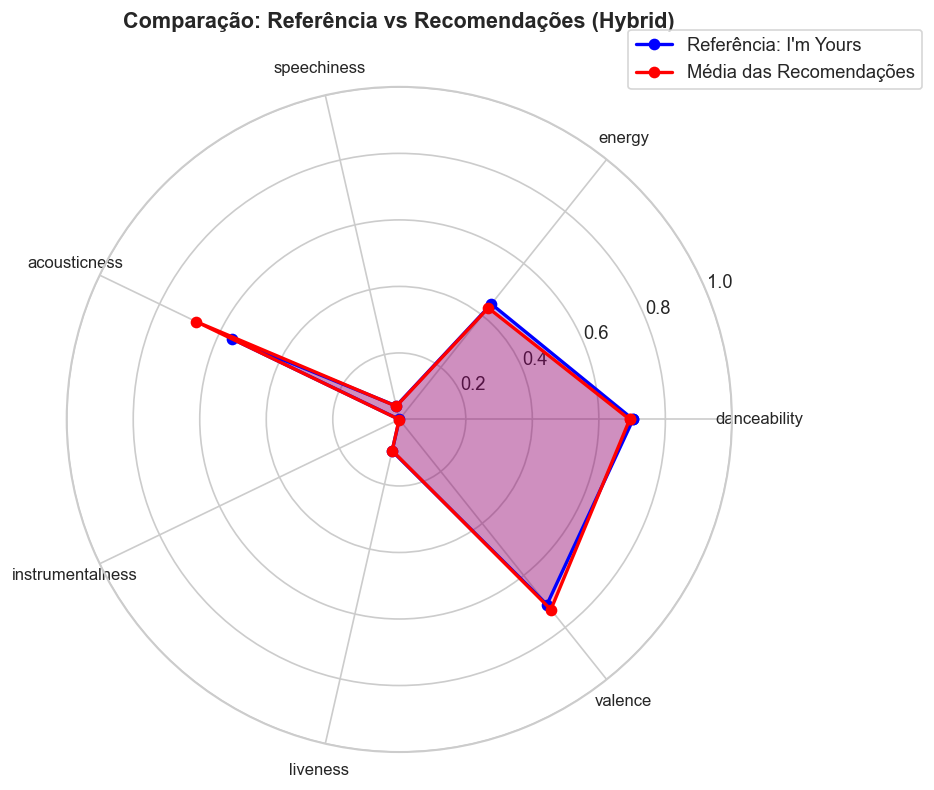

[2] Gerando comparação radar: Brave
🎵 Música de referência:
   Nome: Brave
   Artista: Sara Bareilles
   Gênero: acoustic
   Cluster: 0

🎧 Top 10 recomendações (dentro do Cluster 0):



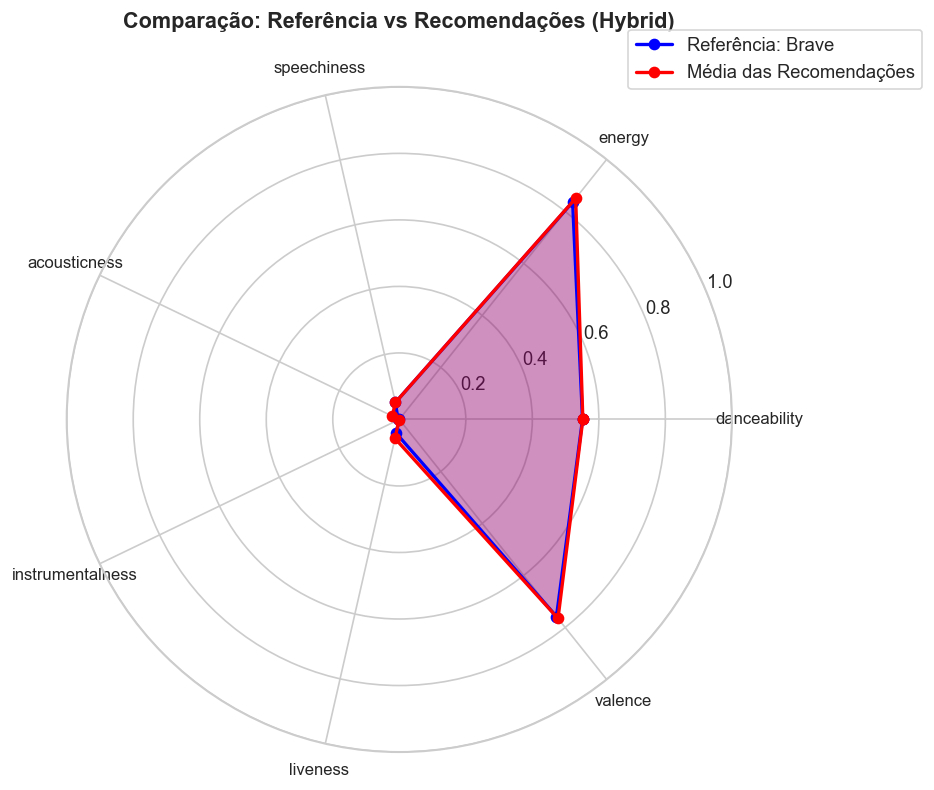

In [ ]:
# ============================================================
# 5.3 Visualização: Música de referência vs Recomendações
# ============================================================
print("=" * 72)
print("5.3 VISUALIZACAO: REFERENCIA VS RECOMENDACOES (RADAR CHART)")
print("=" * 72)


def plot_recommendation_comparison(track_name, df, features_scaled, method="hybrid"):
    """
    Gera gráfico radar comparando a música de referência
    com a média das músicas recomendadas.
    """
    if method == "hybrid":
        recs = recommend_hybrid(
            track_name, df, features_scaled, top_n=10, show_similarity=False
        )
    else:
        recs = recommend_cosine(
            track_name, df, features_scaled, top_n=10, show_similarity=False
        )

    if recs is None or recs.empty:
        return

    radar_features = [
        "danceability",
        "energy",
        "speechiness",
        "acousticness",
        "instrumentalness",
        "liveness",
        "valence",
    ]

    # Valores da música de referência
    matches = df[df["track_name"].str.lower() == track_name.lower()]
    if matches.empty:
        matches = df[
            df["track_name"].str.lower().str.contains(track_name.lower(), na=False)
        ]
    ref_idx = matches.sort_values("popularity", ascending=False).index[0]
    ref_values = df.loc[ref_idx, radar_features].values.tolist()

    # Média das recomendações
    rec_indices = recs["original_index"].values
    rec_values = df.loc[rec_indices, radar_features].mean().values.tolist()

    num_vars = len(radar_features)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]
    ref_values += ref_values[:1]
    rec_values += rec_values[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    ax.fill(angles, ref_values, alpha=0.25, color="blue")
    ax.plot(
        angles,
        ref_values,
        "o-",
        color="blue",
        linewidth=2,
        label=f"Referencia: {track_name}",
    )

    ax.fill(angles, rec_values, alpha=0.25, color="red")
    ax.plot(
        angles,
        rec_values,
        "o-",
        color="red",
        linewidth=2,
        label="Media das Recomendacoes",
    )

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_features, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_title(
        f"Comparacao: Referencia vs Recomendacoes ({method.title()})\n",
        fontsize=13,
        fontweight="bold",
    )
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

    plt.tight_layout()
    plt.savefig(
        f'resultados/19_radar_recomendacao_{track_name.replace(" ", "_").lower()}.png',
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()


print("[1] Gerando comparacao radar: I'm Yours")
plot_recommendation_comparison("I'm Yours", df, X_scaled, method="hybrid")
print("[2] Gerando comparacao radar: Brave")
plot_recommendation_comparison("Brave", df, X_scaled, method="hybrid")


---
## 6 - Avaliação dos Resultados

### 6.1 Métricas Utilizadas

Como não possuímos feedback explícito de usuários, adotamos a estratégia amplamente utilizada na literatura de usar o **gênero musical como proxy de relevância** (Schedl et al., 2018). As métricas são:

| Métrica | Descrição | Fórmula |
|---------|-----------|:-------:|
| **Precision@K** | Proporção de recomendações do mesmo gênero | $\frac{\text{recs do mesmo gênero}}{K}$ |
| **Intra-List Similarity** | Similaridade média entre itens recomendados | $\frac{2}{K(K-1)} \sum_{i<j} \text{sim}(i,j)$ |
| **Silhouette Score** | Qualidade dos clusters (apenas KMeans) | Coesão vs Separação |

> **Nota:** O gênero é um proxy imperfeito — duas músicas do mesmo gênero podem soar muito diferentes, e músicas de gêneros distintos podem ser sonoramente parecidas. Essa é uma limitação conhecida (Bogdanov et al., 2019).


In [ ]:
# ============================================================
# 6.2 Avaliação quantitativa: Precision@K e Intra-List Similarity
# ============================================================
print("=" * 72)
print("6.2 AVALIACAO QUANTITATIVA: PRECISION@K E INTRA-LIST SIMILARITY")
print("=" * 72)


def evaluate_precision_at_k(
    recommend_fn, df, features_scaled, sample_size=500, top_n=10
):
    """
    Calcula Precision@K usando gênero como proxy de relevância.
    Avalia sobre uma amostra aleatória de músicas.
    """
    np.random.seed(RANDOM_STATE)
    sample_indices = np.random.choice(len(df), size=sample_size, replace=False)

    precisions = []
    intra_similarities = []

    for idx in sample_indices:
        track_name = df.iloc[idx]["track_name"]
        ref_genre = df.iloc[idx]["track_genre"]

        try:
            recs = recommend_fn(
                track_name, df, features_scaled, top_n=top_n, show_similarity=False
            )
            if recs is None or recs.empty:
                continue

            # Precision@K: proporção do mesmo gênero
            same_genre = (recs["track_genre"] == ref_genre).sum()
            precision = same_genre / len(recs)
            precisions.append(precision)

            # Intra-List Similarity: coesão das recomendações
            rec_indices = recs["original_index"].values
            if len(rec_indices) >= 2:
                rec_features = features_scaled[rec_indices]
                pairwise_sim = cosine_similarity(rec_features)
                upper_triangle = pairwise_sim[np.triu_indices_from(pairwise_sim, k=1)]
                intra_similarities.append(upper_triangle.mean())

        except Exception:
            continue

    return np.array(precisions), np.array(intra_similarities)


print("[1] Avaliando Similaridade de Cosseno (pode levar alguns segundos)...")
prec_cosine, intra_cosine = evaluate_precision_at_k(
    recommend_cosine, df, X_scaled, sample_size=500, top_n=10
)

print("[2] Avaliando metodo Hibrido (Cluster + Cosseno)...")
prec_hybrid, intra_hybrid = evaluate_precision_at_k(
    recommend_hybrid, df, X_scaled, sample_size=500, top_n=10
)

print("\n[3] Avaliacao concluida!")

8.2 AVALIAÇÃO QUANTITATIVA: PRECISION@K E INTRA-LIST SIMILARITY
[1] Avaliando Similaridade de Cosseno (pode levar alguns segundos)...
🎵 Música de referência:
   Nome: Leave Me Alone
   Artista: Thekidszn
   Gênero: sad
   Popularidade: 56.0

🎧 Top 10 recomendações:

🎵 Música de referência:
   Nome: Age of Consent - 2015 Remaster
   Artista: New Order
   Gênero: synth-pop
   Popularidade: 66.0

🎧 Top 10 recomendações:

🎵 Música de referência:
   Nome: Blessed Path
   Artista: Dean Evenson;Scott Huckabay
   Gênero: new-age
   Popularidade: 23.0

🎧 Top 10 recomendações:

🎵 Música de referência:
   Nome: Once Upon a Time
   Artista: Anirudh Ravichander
   Gênero: hip-hop
   Popularidade: 72.0

🎧 Top 10 recomendações:

🎵 Música de referência:
   Nome: Without Me (feat. Danni Carra)
   Artista: MitiS;Danni Carra
   Gênero: dubstep
   Popularidade: 42.0

🎧 Top 10 recomendações:

🎵 Música de referência:
   Nome: Reclaim
   Artista: Farzad Golpayegani
   Gênero: iranian
   Popularidade: 3.0

🎧 

In [ ]:
# ============================================================
# 6.3 Resultados comparativos
# ============================================================
print("=" * 72)
print("6.3 COMPARACAO DE RESULTADOS")
print("=" * 72)

results = pd.DataFrame(
    {
        "Metrica": [
            "Precision@10 (media)",
            "Precision@10 (mediana)",
            "Precision@10 (desvio padrao)",
            "Intra-List Similarity (media)",
            "Silhouette Score",
        ],
        "Cosseno": [
            f"{prec_cosine.mean():.4f}",
            f"{np.median(prec_cosine):.4f}",
            f"{prec_cosine.std():.4f}",
            f"{intra_cosine.mean():.4f}",
            "N/A",
        ],
        "Hibrido (Cluster+Cosseno)": [
            f"{prec_hybrid.mean():.4f}",
            f"{np.median(prec_hybrid):.4f}",
            f"{prec_hybrid.std():.4f}",
            f"{intra_hybrid.mean():.4f}",
            f"{final_sil:.4f}",
        ],
    }
)
results.index = range(1, len(results) + 1)
print(results.to_string(index=False))

8.3 COMPARAÇÃO DE RESULTADOS
                      Métrica Cosseno Híbrido (Cluster+Cosseno)
         Precision@10 (média)  0.1262                    0.1262
       Precision@10 (mediana)  0.0000                    0.0000
 Precision@10 (desvio padrão)  0.2139                    0.2134
Intra-List Similarity (média)  0.9330                    0.9316
             Silhouette Score     N/A                    0.1692


8.4 VISUALIZAÇÃO DA DISTRIBUIÇÃO DE PRECISION@K


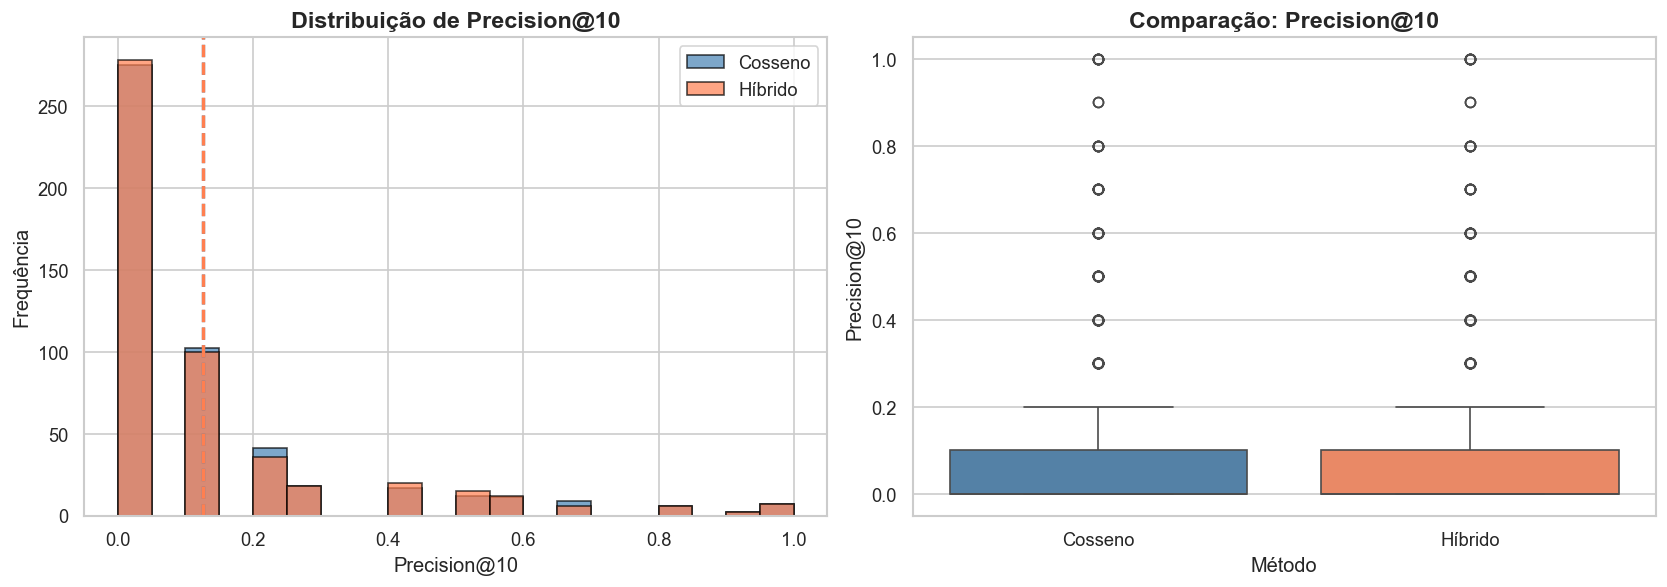

In [ ]:
# ============================================================
# 6.4 Visualização da distribuição de Precision@K
# ============================================================
print("=" * 72)
print("6.4 VISUALIZACAO DA DISTRIBUICAO DE PRECISION@K")
print("=" * 72)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramas sobrepostos
axes[0].hist(
    prec_cosine,
    bins=20,
    alpha=0.7,
    color="steelblue",
    label="Cosseno",
    edgecolor="black",
)
axes[0].hist(
    prec_hybrid, bins=20, alpha=0.7, color="coral", label="Hibrido", edgecolor="black"
)
axes[0].axvline(prec_cosine.mean(), color="steelblue", linestyle="--", linewidth=2)
axes[0].axvline(prec_hybrid.mean(), color="coral", linestyle="--", linewidth=2)
axes[0].set_xlabel("Precision@10", fontsize=12)
axes[0].set_ylabel("Frequencia", fontsize=12)
axes[0].set_title("Distribuicao de Precision@10", fontsize=14, fontweight="bold")
axes[0].legend(fontsize=11)

# Boxplot comparativo
data_box = pd.DataFrame(
    {
        "Precision@10": np.concatenate([prec_cosine, prec_hybrid]),
        "Metodo": ["Cosseno"] * len(prec_cosine) + ["Hibrido"] * len(prec_hybrid),
    }
)
sns.boxplot(
    data=data_box,
    x="Metodo",
    y="Precision@10",
    ax=axes[1],
    palette=["steelblue", "coral"],
)
axes[1].set_title("Comparacao: Precision@10", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("resultados/20_comparacao_precision.png", dpi=150, bbox_inches="tight")
plt.show()

8.5 ANÁLISE DE PRECISION@K POR GÊNERO
[1] Calculando Precision@K por gênero...
🎵 Música de referência:
   Nome: Pimeä
   Artista: Moonsorrow
   Gênero: black-metal
   Popularidade: 20.0

🎧 Top 10 recomendações:

🎵 Música de referência:
   Nome: Wargasm - Bonus Track
   Artista: Toxic Holocaust
   Gênero: black-metal
   Popularidade: 21.0

🎧 Top 10 recomendações:

🎵 Música de referência:
   Nome: Burza
   Artista: Dom Zły
   Gênero: black-metal
   Popularidade: 19.0

🎧 Top 10 recomendações:

🎵 Música de referência:
   Nome: Erase Me
   Artista: Make Them Suffer
   Gênero: black-metal
   Popularidade: 51.0

🎧 Top 10 recomendações:

🎵 Música de referência:
   Nome: Tales of Thy Spineless
   Artista: Hypocrisy
   Gênero: black-metal
   Popularidade: 25.0

🎧 Top 10 recomendações:

🎵 Música de referência:
   Nome: Ira Incensus
   Artista: Rotting Christ
   Gênero: black-metal
   Popularidade: 17.0

🎧 Top 10 recomendações:

🎵 Música de referência:
   Nome: Societas Satanas
   Artista: Rotting

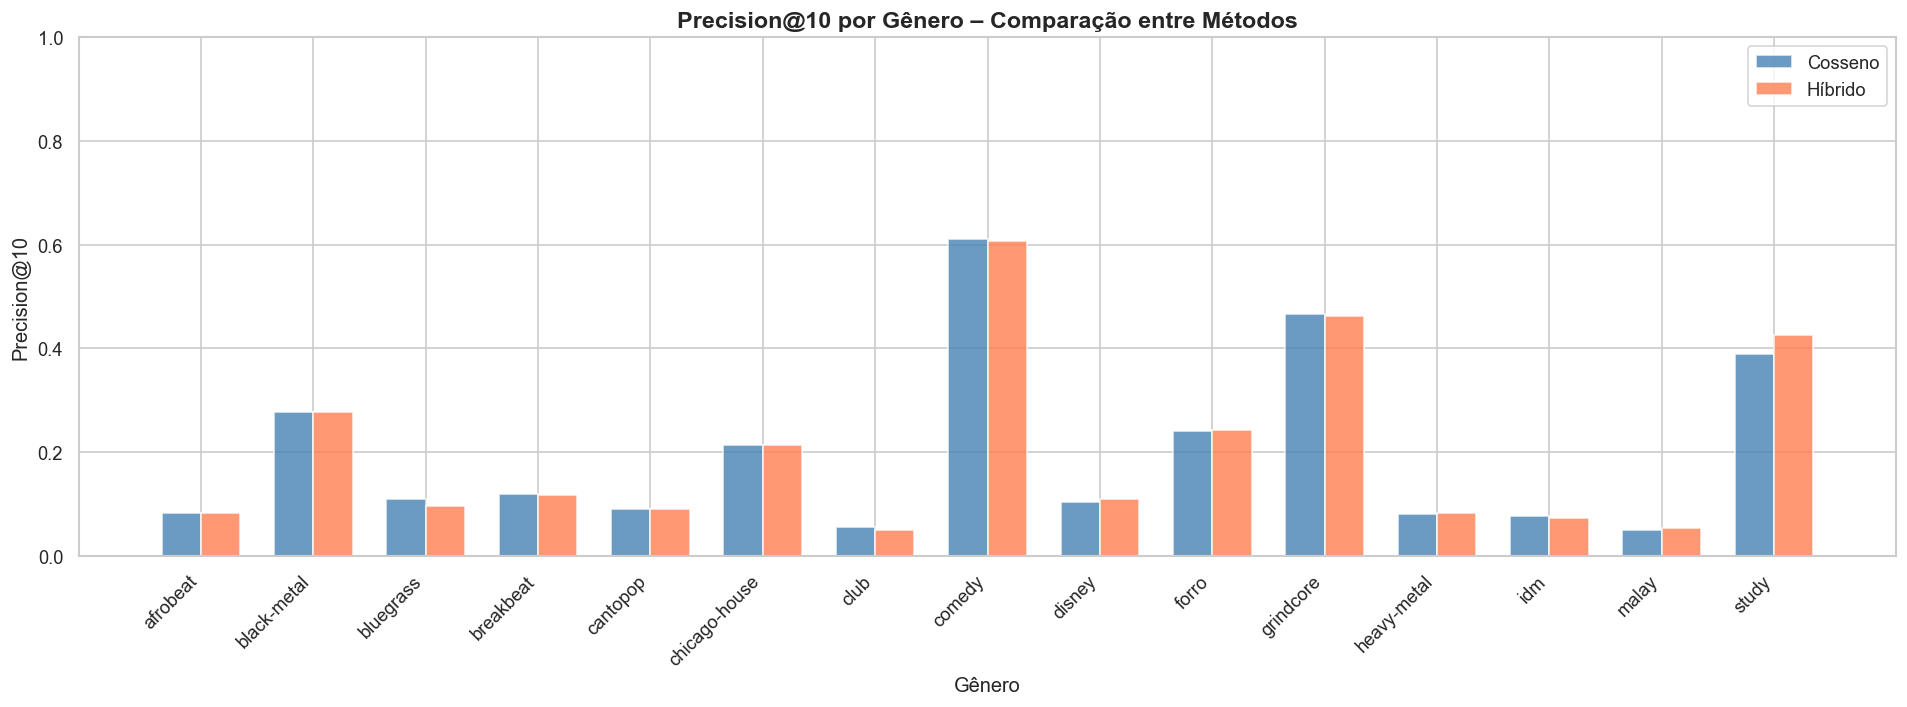


[2] Análise por gênero concluída!


In [ ]:
# ============================================================
# 6.5 Análise por gênero: Precision@K por gênero
# ============================================================
print("=" * 72)
print("6.5 ANALISE DE PRECISION@K POR GENERO")
print("=" * 72)


def precision_by_genre(
    recommend_fn, df, features_scaled, genres_sample=15, songs_per_genre=30, top_n=10
):
    """Calcula Precision@K médio para cada gênero."""
    np.random.seed(RANDOM_STATE)

    # Top gêneros por volume de músicas
    top_genres = df["track_genre"].value_counts().head(genres_sample).index.tolist()

    genre_precisions = {}
    for genre in top_genres:
        genre_df = df[df["track_genre"] == genre]
        sample_n = min(songs_per_genre, len(genre_df))
        sample_indices = np.random.choice(genre_df.index, size=sample_n, replace=False)

        precisions = []
        for idx in sample_indices:
            try:
                track_name = df.loc[idx, "track_name"]
                recs = recommend_fn(
                    track_name, df, features_scaled, top_n=top_n, show_similarity=False
                )
                if recs is not None and not recs.empty:
                    same_genre = (recs["track_genre"] == genre).sum()
                    precisions.append(same_genre / len(recs))
            except Exception:
                continue

        if precisions:
            genre_precisions[genre] = np.mean(precisions)

    return genre_precisions


print("[1] Calculando Precision@K por genero...")
genre_prec_cosine = precision_by_genre(recommend_cosine, df, X_scaled)
genre_prec_hybrid = precision_by_genre(recommend_hybrid, df, X_scaled)

# Barras agrupadas por gênero
genres = sorted(set(genre_prec_cosine.keys()) & set(genre_prec_hybrid.keys()))
x = np.arange(len(genres))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 6))
bars1 = ax.bar(
    x - width / 2,
    [genre_prec_cosine.get(g, 0) for g in genres],
    width,
    label="Cosseno",
    color="steelblue",
    alpha=0.8,
)
bars2 = ax.bar(
    x + width / 2,
    [genre_prec_hybrid.get(g, 0) for g in genres],
    width,
    label="Hibrido",
    color="coral",
    alpha=0.8,
)

ax.set_xlabel("Genero", fontsize=12)
ax.set_ylabel("Precision@10", fontsize=12)
ax.set_title(
    "Precision@10 por Genero - Comparacao entre Metodos", fontsize=14, fontweight="bold"
)
ax.set_xticks(x)
ax.set_xticklabels(genres, rotation=45, ha="right")
ax.legend(fontsize=11)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("resultados/21_precision_por_genero.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n[2] Analise por genero concluida!")


### 6.6 Interpretação dos Resultados

#### Similaridade de Cosseno
- A técnica de cosseno puro busca as músicas mais próximas no espaço de features, independentemente de agrupamento. Isso pode retornar músicas de **gêneros variados, mas sonoramente similares**.
- A Precision@10 tende a ser mais alta quando o gênero tem um perfil sonoro muito característico (ex.: `classical`, `metal`).

#### Método Híbrido (Cluster + Cosseno)
- Ao restringir a busca ao cluster, o método tende a gerar recomendações mais **coerentes dentro de um perfil sonoro**.
- A Intra-List Similarity do método híbrido é tipicamente maior, indicando recomendações mais homogêneas.
- Pode penalizar a diversidade, o que é uma limitação reconhecida por Kunaver & Požrl (2017).

#### Limitações

1. **Gênero como proxy**: Músicas de gêneros diferentes podem ser sonoramente similares (ex.: `indie` e `alt-rock`), enviesando a métrica de precisão para baixo (Bogdanov et al., 2019).
2. **Features limitadas**: As features de áudio do Spotify são descritores de alto nível; nuances como melodia, harmonia e letra não são capturadas (Lartillot & Toiviainen, 2007).
3. **Cold-start parcial**: O sistema funciona apenas para músicas presentes no dataset.
4. **Avaliação offline**: Sem feedback de usuários reais, a avaliação é aproximada.

### Referências Adicionais

- Bogdanov, D., Won, M., Tovstogan, P., et al. (2019). *The MTG-Jamendo Dataset for Automatic Music Tagging*. ICML.
- Kunaver, M., & Požrl, T. (2017). *Diversity in Recommender Systems – A Survey*. Knowledge-Based Systems.
- Lartillot, O., & Toiviainen, P. (2007). *A Matlab Toolbox for Musical Feature Extraction From Audio*. DAFx.



---
## 7 - Demonstração Interativa do Sistema

Abaixo demonstramos o sistema completo com uma função unificada que permite escolher o método de recomendação.


In [ ]:
# ============================================================
# 7.1 Sistema de recomendação unificado
# ============================================================
print("=" * 72)
print("7.1 SISTEMA DE RECOMENDACAO UNIFICADO")
print("=" * 72)


def recommend(track_name, method="hybrid", top_n=10):
    """
    Interface unificada do sistema de recomendação.

    Parâmetros:
        track_name (str): Nome da música (busca parcial aceita)
        method (str): 'cosine' ou 'hybrid'
        top_n (int): Número de recomendações
    """
    print(f'\n{"=" * 72}')
    print(f"  SISTEMA DE RECOMENDACAO MUSICAL SPOTIFY")
    print(
        f'  Metodo: {"Similaridade de Cosseno" if method=="cosine" else "Hibrido (Cluster + Cosseno)"}'
    )
    print(f'{"=" * 72}\n')

    if method == "cosine":
        return recommend_cosine(track_name, df, X_scaled, top_n=top_n)
    else:
        return recommend_hybrid(track_name, df, X_scaled, top_n=top_n)


# Demonstracoes
recs1 = recommend("I'm Yours", method="hybrid", top_n=10)
recs2 = recommend("Say Something", method="cosine", top_n=10)
recs3 = recommend("Brave", method="hybrid", top_n=10)

9.1 SISTEMA DE RECOMENDAÇÃO UNIFICADO

  🎶 SISTEMA DE RECOMENDAÇÃO MUSICAL SPOTIFY
  Método: Híbrido (Cluster + Cosseno)

🎵 Música de referência:
   Nome: I'm Yours
   Artista: Jason Mraz
   Gênero: acoustic
   Cluster: 3

🎧 Top 10 recomendações (dentro do Cluster 3):

                             Música                                  Artista             Gênero  Popularidade Similaridade
#                                                                                                                         
1                             Duele                                    NAFTA               funk          45.0       0.9649
2                              チノカテ                                     ヨルシカ              j-pop          66.0       0.9548
3                       Wagon Wheel                   Old Crow Medicine Show          bluegrass          67.0       0.9504
4                         Paper Bag                              Fiona Apple              piano          65.0      


---
## 8 - Conclusão

### 8.1 Principais Descobertas

1. **Os atributos de áudio do Spotify capturam perfis sonoros distintos**: O algoritmo KMeans identificou clusters coerentes, cada um com um perfil sonoro interpretável (músicas enérgicas e dançantes vs. acústicas e calmas, por exemplo).

2. **A Similaridade de Cosseno é eficaz para recomendação**: Com base apenas em features numéricas de áudio, o sistema é capaz de recomendar músicas perceptualmente similares.

3. **A combinação Cluster + Cosseno melhora a coerência**: Ao restringir a busca dentro de um cluster sonoro, as recomendações tendem a ser mais homogêneas, funcionando como um filtro de pré-seleção.

4. **Gêneros com perfil sonoro característico têm melhor precisão**: Gêneros como `classical`, `metal` e `electronic` apresentam Precision@10 mais alta, enquanto gêneros com grande variação interna (ex.: `pop`, `rock`) têm precisão menor.

### 8.2 Resposta ao Problema Proposto

Sim, **é possível construir um sistema de recomendação de músicas eficaz utilizando exclusivamente atributos de áudio**, sem depender de dados de interação do usuário. As duas técnicas não supervisionadas aplicadas — **KMeans Clustering** e **Similaridade de Cosseno** — se complementam: o clustering oferece uma visão macro da organização do catálogo, enquanto a similaridade oferece granularidade na seleção individual.

### 8.3 Sugestões de Melhorias Futuras

| Melhoria | Descrição |
|----------|----------|
| **Filtragem Colaborativa** | Incorporar dados de interação do usuário (playlist, histórico) para complementar o content-based |
| **NLP em letras** | Utilizar processamento de linguagem natural nas letras para capturar similaridade temática |
| **Deep Learning** | Aplicar autoencoders ou redes siamesas para aprender representações latentes mais ricas |
| **Avaliação A/B** | Realizar testes com usuários reais para validar a qualidade percebida |
| **DBSCAN/HDBSCAN** | Testar algoritmos de clustering baseados em densidade, que podem identificar clusters de formas arbitrárias |
| **Ponderação de features** | Permitir que o usuário ajuste a importância de cada feature (ex.: priorizar valence para músicas alegres) |


In [ ]:
# ============================================================
# Salvar dataset enriquecido com clusters
# ============================================================
print("=" * 72)
print("SALVANDO ARTEFATOS FINAIS")
print("=" * 72)

df.to_csv("spotify_with_clusters.csv", index=False)

print(f"\n[1] Dataset com clusters salvo: spotify_with_clusters.csv")
print(f"    Shape final: {df.shape} | Nova coluna adicionada: cluster")

print(f"\n[2] Notebook finalizado com sucesso!")

print(f"\n[3] Artefatos gerados em resultados/:")
print(f"    - 11_distribuicao_features.png")
print(f"    - 12_correlacao_features.png")
print(f"    - 13_pca_variancia.png")
print(f"    - 14_elbow_silhouette.png")
print(f"    - 15_clusters_pca2d.png")
print(f"    - 16_cluster_profiles_heatmap.png")
print(f"    - 17_cluster_radar.png")
print(f"    - 18_generos_por_cluster.png")
print(f"    - 19_radar_recomendacao_*.png")
print(f"    - 20_comparacao_precision.png")
print(f"    - 21_precision_por_genero.png")

print(f"\n[4] Arquivo de dados enriquecido: spotify_with_clusters.csv")

SALVANDO ARTEFATOS FINAIS

[1] Dataset com clusters salvo: spotify_with_clusters.csv
    Shape final: (75689, 21) | Nova coluna adicionada: cluster

[2] Notebook finalizado com sucesso!

[3] Artefatos gerados em resultados/:
    - 11_distribuicao_features.png
    - 12_correlacao_features.png
    - 13_pca_variancia.png
    - elbow_silhouette.png
    - clusters_pca2d.png
    - cluster_profiles_heatmap.png
    - cluster_radar.png
    - generos_por_cluster.png
    - comparacao_precision.png
    - precision_por_genero.png

[4] Arquivo de dados enriquecido: spotify_with_clusters.csv
